# Análisis de Préstamos Hipotecarios con Machine Learning
## Interpretabilidad de modelos, consideraciones éticas y clustering

---

**Asignatura:** Análisis de datos en el ecosistema Python  
**Dataset:** HMDA (Home Mortgage Disclosure Act) - Utah 2022  
**Repositorio:** hmda-loan-approval-ml-analysis

---

Este notebook realiza un análisis completo de datos de préstamos hipotecarios utilizando técnicas de machine learning, con especial énfasis en:

- 📊 **Evaluación de modelos**: métricas de rendimiento y matriz de confusión
- 🔍 **Interpretabilidad**: SHAP, LIME e importancia de variables
- ⚖️ **Ética y fairness**: detección de sesgos y análisis de equidad en las decisiones de concesión de hipotecas
- 🧩 **Clustering**: segmentación de solicitantes y detección de perfiles atípicos

## 1. Introducción al proyecto

### 1.1 ¿Qué es el dataset HMDA?

El **Home Mortgage Disclosure Act (HMDA)** es una ley federal de Estados Unidos que requiere que las instituciones financieras reporten públicamente datos sobre préstamos hipotecarios. Esta información permite:

- Determinar si las instituciones financieras están atendiendo las necesidades de vivienda de sus comunidades
- Ayudar a los funcionarios públicos a distribuir inversiones del sector público
- Identificar posibles patrones de discriminación en la concesión de préstamos

Los datos HMDA incluyen información detallada sobre cada solicitud de préstamo hipotecario, incluyendo:
- Características del préstamo (monto, tipo, propósito)
- Características del solicitante (ingresos, raza, sexo, edad)
- Información geográfica
- Resultado de la solicitud (aprobada, denegada, etc.)

### 1.2 ¿Por qué Utah 2022?

Para este proyecto se ha seleccionado el subconjunto de datos correspondiente al estado de **Utah** del año **2022** por las siguientes razones:

1. **Viabilidad computacional**: el dataset nacional completo contiene millones de registros. El subconjunto de Utah ofrece un tamaño manejable para análisis sin comprometer la representatividad.
2. **Datos recientes**: los datos de 2022 reflejan prácticas actuales de concesión de préstamos.
3. **Enfoque de estudio de caso**: permite un análisis profundo de un mercado hipotecario específico, facilitando interpretaciones contextualizadas.

### 1.3 Objetivos del proyecto

Los objetivos concretos de este proyecto son:

1. **Definir y construir el target**: convertir `action_taken` en una variable binaria (aprobado/denegado) y justificar la codificación usada.
2. **Comparar rendimiento de modelos**: entrenar Regresión Logística, Random Forest y Gradient Boosting y comparar **AUC, F1, recall y matriz de confusión** para seleccionar el mejor modelo.
3. **Identificar variables más influyentes**: extraer e interpretar las 10 características con mayor impacto usando **feature importance y SHAP**.
4. **Evaluar sesgos por subgrupos**: medir diferencias de tasas de aprobación y métricas del modelo por **raza, sexo y edad**, y cuantificar brechas.
5. **Analizar patrones no supervisados**: aplicar **K-Means y DBSCAN** para descubrir perfiles de solicitantes y relacionarlos con la aprobación.
6. **Extraer conclusiones accionables**: sintetizar hallazgos sobre desempeño, interpretabilidad y equidad para recomendaciones finales.

## 2. Descripción del conjunto de datos

### 2.1 Origen de los datos

Los datos utilizados en este proyecto provienen del **Consumer Financial Protection Bureau (CFPB)**, que administra la recopilación y publicación de datos bajo el HMDA. El dataset específico ha sido obtenido de Kaggle:

📁 **Fuente**: [Utah HMDA Data 2018-2022](https://www.kaggle.com/datasets/richcordova/utah-hmda-data-2018-2022/data?select=utah_hmda_data_2022.csv)

### 2.2 Estructura general del dataset

El dataset de Utah 2022 contiene información sobre solicitudes de préstamos hipotecarios procesadas por instituciones financieras en el estado de Utah durante el año 2022. Cada fila representa una solicitud de préstamo individual.

### 2.3 Variables principales

| Variable | Descripción | Tipo |
|----------|-------------|------|
| `action_taken` | Resultado de la solicitud (aprobada, denegada, retirada, etc.) | Categórica (Target) |
| `loan_amount` | Monto del préstamo solicitado | Numérica |
| `income` | Ingresos anuales del solicitante (en miles de dólares) | Numérica |
| `loan_to_value_ratio` | Ratio préstamo-valor de la propiedad | Numérica |
| `debt_to_income_ratio` | Ratio deuda-ingresos del solicitante | Categórica/Numérica |
| `property_value` | Valor estimado de la propiedad | Numérica |
| `loan_type` | Tipo de préstamo (convencional, FHA, VA, etc.) | Categórica |
| `loan_purpose` | Propósito del préstamo (compra, refinanciamiento, etc.) | Categórica |
| `occupancy_type` | Tipo de ocupación de la propiedad | Categórica |
| `derived_race` | Raza del solicitante principal | Categórica (Sensible) |
| `derived_sex` | Sexo del solicitante principal | Categórica (Sensible) |
| `applicant_age` | Edad del solicitante | Categórica (Sensible) |
| `county_code` | Código del condado | Categórica |

### 2.4 Atributos sensibles para el análisis ético

⚠️ **Atributos sensibles identificados:**

Los siguientes atributos se consideran **sensibles** desde una perspectiva ética y legal, ya que están protegidos bajo leyes de no discriminación:

- **`derived_race`**: raza/etnicidad del solicitante
- **`derived_sex`**: sexo/género del solicitante  
- **`applicant_age`**: edad del solicitante

Estos atributos serán analizados específicamente en la sección de análisis ético para detectar posibles sesgos en las predicciones del modelo.

## 3. Distribución del trabajo

### 👤 Robert: preprocesamiento y modelado

**Responsabilidades:**
- Carga y limpieza inicial de los datos
- Análisis exploratorio de datos (EDA)
- Construcción de pipelines de preprocesamiento
- Selección y codificación de variables
- Entrenamiento de modelos de machine learning
- Evaluación inicial mediante métricas de rendimiento

**Secciones del notebook:** 4, 5, 6, 7

---

### 👤 Rodrigo: interpretabilidad de modelos

**Responsabilidades:**
- Implementación de análisis SHAP (SHapley Additive exPlanations)
- Implementación de explicaciones LIME (Local Interpretable Model-agnostic Explanations)
- Análisis de importancia de variables
- Interpretación del comportamiento global y local del modelo
- Visualización de explicaciones

**Secciones del notebook:** 8

---

### 👤 Juan: análisis ético y detección de sesgos

**Responsabilidades:**
- Análisis de rendimiento por subgrupos (fairness)
- Detección de sesgos en datos y predicciones
- Comparación de métricas entre grupos sensibles
- Discusión crítica de implicaciones éticas
- Redacción de conclusiones y recomendaciones

**Secciones del notebook:** 9

### 🫂 Conjunto: análisis de clustering (segmentación de solicitantes)

**Responsabilidades:**
- Preparación de los datos para aprendizaje no supervisado
- Implementación de K-Means con Método del Codo y Silhouette Score
- Implementación de DBSCAN para detección de solicitudes atípicas
- Clustering Jerárquico y comparativa de algoritmos
- Perfilado e interpretación de los clusters descubiertos
- Análisis de la relación entre clusters y decisiones de aprobación
- Estudio de la distribución demográfica por cluster (dimensión ética)

**Secciones del notebook:** 10

---

## 4. Carga de Datos y Exploración Inicial

### 4.1 Configuración del Entorno

Primero importamos todas las librerías necesarias para el análisis.

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuración de visualización
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# Ignorar warnings
import warnings
warnings.filterwarnings('ignore')

print("Librerías cargadas correctamente ✓")

Librerías cargadas correctamente ✓


### 4.2 Carga del Dataset

Cargamos el dataset de Utah HMDA 2022 desde la carpeta `data/`.

In [2]:
# Definir la ruta al archivo CSV
data_path = Path('data') / 'utah_hmda_data_2022.csv'

# Verificar que el archivo existe
if data_path.exists():
    # Cargar el dataset
    df = pd.read_csv(data_path, low_memory=False)
    print(f"✓ Dataset cargado exitosamente")
    print(f"  Ruta: {data_path}")
    print(f"  Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
else:
    print(f"✗ ERROR: No se encontró el archivo en {data_path}")
    print("  Verifica que el archivo 'utah_hmda_data_2022.csv' esté en la carpeta 'data'")

✓ Dataset cargado exitosamente
  Ruta: data\utah_hmda_data_2022.csv
  Dimensiones: 226,790 filas × 99 columnas


In [ ]:
df

### 4.3 Exploración Inicial del Dataset

Examinamos la estructura básica del dataset: primeras filas, tipos de datos e información general.

In [ ]:
# Visualizar las primeras filas del dataset

In [ ]:
# Información general del dataset

In [ ]:
# Estadísticas descriptivas de variables numéricas

### 4.4 Análisis de Valores Faltantes

Identificamos las columnas con valores nulos y su porcentaje respecto al total.

### 4.5 Exploración de la Variable Objetivo

La variable `action_taken` indica el resultado de la solicitud de préstamo. Analizamos su distribución.

### 4.6 Exploración de Variables Clave

Visualizamos la distribución de algunas variables importantes para el análisis.

## 5. Preprocesamiento de Datos

En esta sección realizamos el preprocesamiento necesario para preparar los datos para el modelado:
- Selección de variables relevantes
- Creación de la variable objetivo binaria
- Tratamiento de valores faltantes
- Codificación de variables categóricas
- División train/test con pipelines para evitar data leakage

### 5.1 Selección de Variables y Creación de Variable Objetivo

### 5.2 Filtrado y Limpieza de Datos

### 5.3 Construcción de Pipelines de Preprocesamiento

Utilizamos pipelines de scikit-learn para evitar **data leakage** y asegurar que las transformaciones se apliquen correctamente en train y test.

## 6. Entrenamiento de Modelos

En esta sección entrenamos diferentes modelos de machine learning para predecir la aprobación de préstamos hipotecarios.

### Justificación de los modelos seleccionados:

1. **Regresión Logística**: modelo base interpretable que nos permite entender directamente la influencia de cada variable a través de sus coeficientes. Es ideal para establecer una línea base y para explicabilidad.

2. **Random Forest**: modelo ensemble basado en árboles de decisión que captura relaciones no lineales y proporciona importancia de variables de forma nativa. Ofrece buen balance entre rendimiento e interpretabilidad.

3. **Gradient Boosting**: modelo más complejo que suele ofrecer mejor rendimiento pero es más difícil de interpretar. Nos permitirá comparar el trade-off entre precisión e interpretabilidad.

### 6.1 Modelo 1: Regresión Logística (modelo base)

### 6.2 Modelo 2: Random Forest

### 6.3 Modelo 3: Gradient Boosting

## 7. Evaluación de modelos

### 7.1 Métricas de evaluación

### 7.2 Matrices de confusión

### 7.3 Informes de clasificación detallados

## 8. Interpretabilidad del mModelo

### 8.1 Importancia de variables (Feature Importance)

In [4]:
# ============================================================================
# BLOQUE TEMPORAL: Entrenamiento rápido de modelos para testing
# ============================================================================
# Este código prepara datos y entrena modelos básicos de forma rápida.
# ELIMINAR o comentar cuando las secciones 5 y 6 estén completadas.
# ============================================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

print("Preparando datos para entrenamiento temporal...")

# 1. Crear variable objetivo binaria
# action_taken: 1=aprobado, 2=solicitado pero no aceptado, 3=denegado, etc.
# Simplificamos: 1 = aprobado, resto = denegado
df_temp = df.copy()
df_temp['approved'] = (df_temp['action_taken'] == 1).astype(int)

# 2. Seleccionar features básicas (ajustar según disponibilidad en tu dataset)
numeric_features = ['loan_amount', 'income', 'property_value', 'loan_to_value_ratio']
categorical_features = ['loan_type', 'loan_purpose', 'occupancy_type']

# Verificar qué columnas existen realmente
available_numeric = [col for col in numeric_features if col in df_temp.columns]
available_categorical = [col for col in categorical_features if col in df_temp.columns]

print(f"Features numéricas disponibles: {available_numeric}")
print(f"Features categóricas disponibles: {available_categorical}")

# 3. Preparar X e y
all_features = available_numeric + available_categorical

# Convertir columnas numéricas a tipo numérico (maneja valores como "Exempt")
df_temp[available_numeric] = df_temp[available_numeric].apply(
    lambda col: pd.to_numeric(col, errors='coerce')
)

df_temp_clean = df_temp[all_features + ['approved']].dropna()

X = df_temp_clean[all_features]
y = df_temp_clean['approved']

print(f"\nDatos limpios: {len(X)} registros, {len(all_features)} features")
print(f"Distribución target: {y.value_counts().to_dict()}")

# 4. Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Crear pipeline de preprocesamiento
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, available_numeric),
        ('cat', categorical_transformer, available_categorical)
    ])

# 6. Entrenar modelos
print("\n" + "="*60)
print("Entrenando modelos...")
print("="*60)

# Logistic Regression
lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=500))
])
lr_model.fit(X_train, y_train)
print(f"✓ Regresión Logística entrenada - Score: {lr_model.score(X_test, y_test):.4f}")

# Random Forest
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])
rf_model.fit(X_train, y_train)
print(f"✓ Random Forest entrenado - Score: {rf_model.score(X_test, y_test):.4f}")

# Gradient Boosting
gb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(n_estimators=100, random_state=42))
])
gb_model.fit(X_train, y_train)
print(f"✓ Gradient Boosting entrenado - Score: {gb_model.score(X_test, y_test):.4f}")

print("\n" + "="*60)
print("¡Modelos listos para análisis de interpretabilidad!")
print("="*60)
print("\nVariables disponibles:")
print("  - lr_model: Regresión Logística")
print("  - rf_model: Random Forest")
print("  - gb_model: Gradient Boosting")
print("  - X_train, X_test, y_train, y_test")
print("\n⚠️ RECORDATORIO: Reemplazar con modelos finales de las secciones 5-6")

Preparando datos para entrenamiento temporal...
Features numéricas disponibles: ['loan_amount', 'income', 'property_value', 'loan_to_value_ratio']
Features categóricas disponibles: ['loan_type', 'loan_purpose', 'occupancy_type']

Datos limpios: 156656 registros, 7 features
Distribución target: {1: 125292, 0: 31364}

Entrenando modelos...
✓ Regresión Logística entrenada - Score: 0.8002
✓ Random Forest entrenado - Score: 0.8155
✓ Gradient Boosting entrenado - Score: 0.8247

¡Modelos listos para análisis de interpretabilidad!

Variables disponibles:
  - lr_model: Regresión Logística
  - rf_model: Random Forest
  - gb_model: Gradient Boosting
  - X_train, X_test, y_train, y_test

⚠️ RECORDATORIO: Reemplazar con modelos finales de las secciones 5-6


---
**⚠️ BLOQUE TEMPORAL: Entrenamiento Rápido de Modelos**

Este bloque es temporal y se utilizará hasta que se completen las secciones 5 y 6 del notebook. 
Una vez que los modelos estén entrenados en sus secciones correspondientes, este bloque puede eliminarse.


RANDOM FOREST: Importancia de Variables (top 15)
                 feature  importance
num__loan_to_value_ratio    0.309818
             num__income    0.290206
     num__property_value    0.197242
        num__loan_amount    0.155251
     cat__loan_purpose_1    0.013559
     cat__loan_purpose_4    0.007069
     cat__loan_purpose_2    0.004172
    cat__loan_purpose_32    0.003718
   cat__occupancy_type_1    0.003562
   cat__occupancy_type_3    0.003481
    cat__loan_purpose_31    0.003303
        cat__loan_type_2    0.002854
        cat__loan_type_1    0.002534
        cat__loan_type_3    0.001568
   cat__occupancy_type_2    0.001338

GRADIENT BOOSTING: Importancia de Variables (top 15)
                 feature  importance
num__loan_to_value_ratio    0.366064
             num__income    0.313676
     cat__loan_purpose_1    0.109027
     num__property_value    0.072563
        num__loan_amount    0.047554
     cat__loan_purpose_4    0.031178
   cat__occupancy_type_1    0.016228
        c

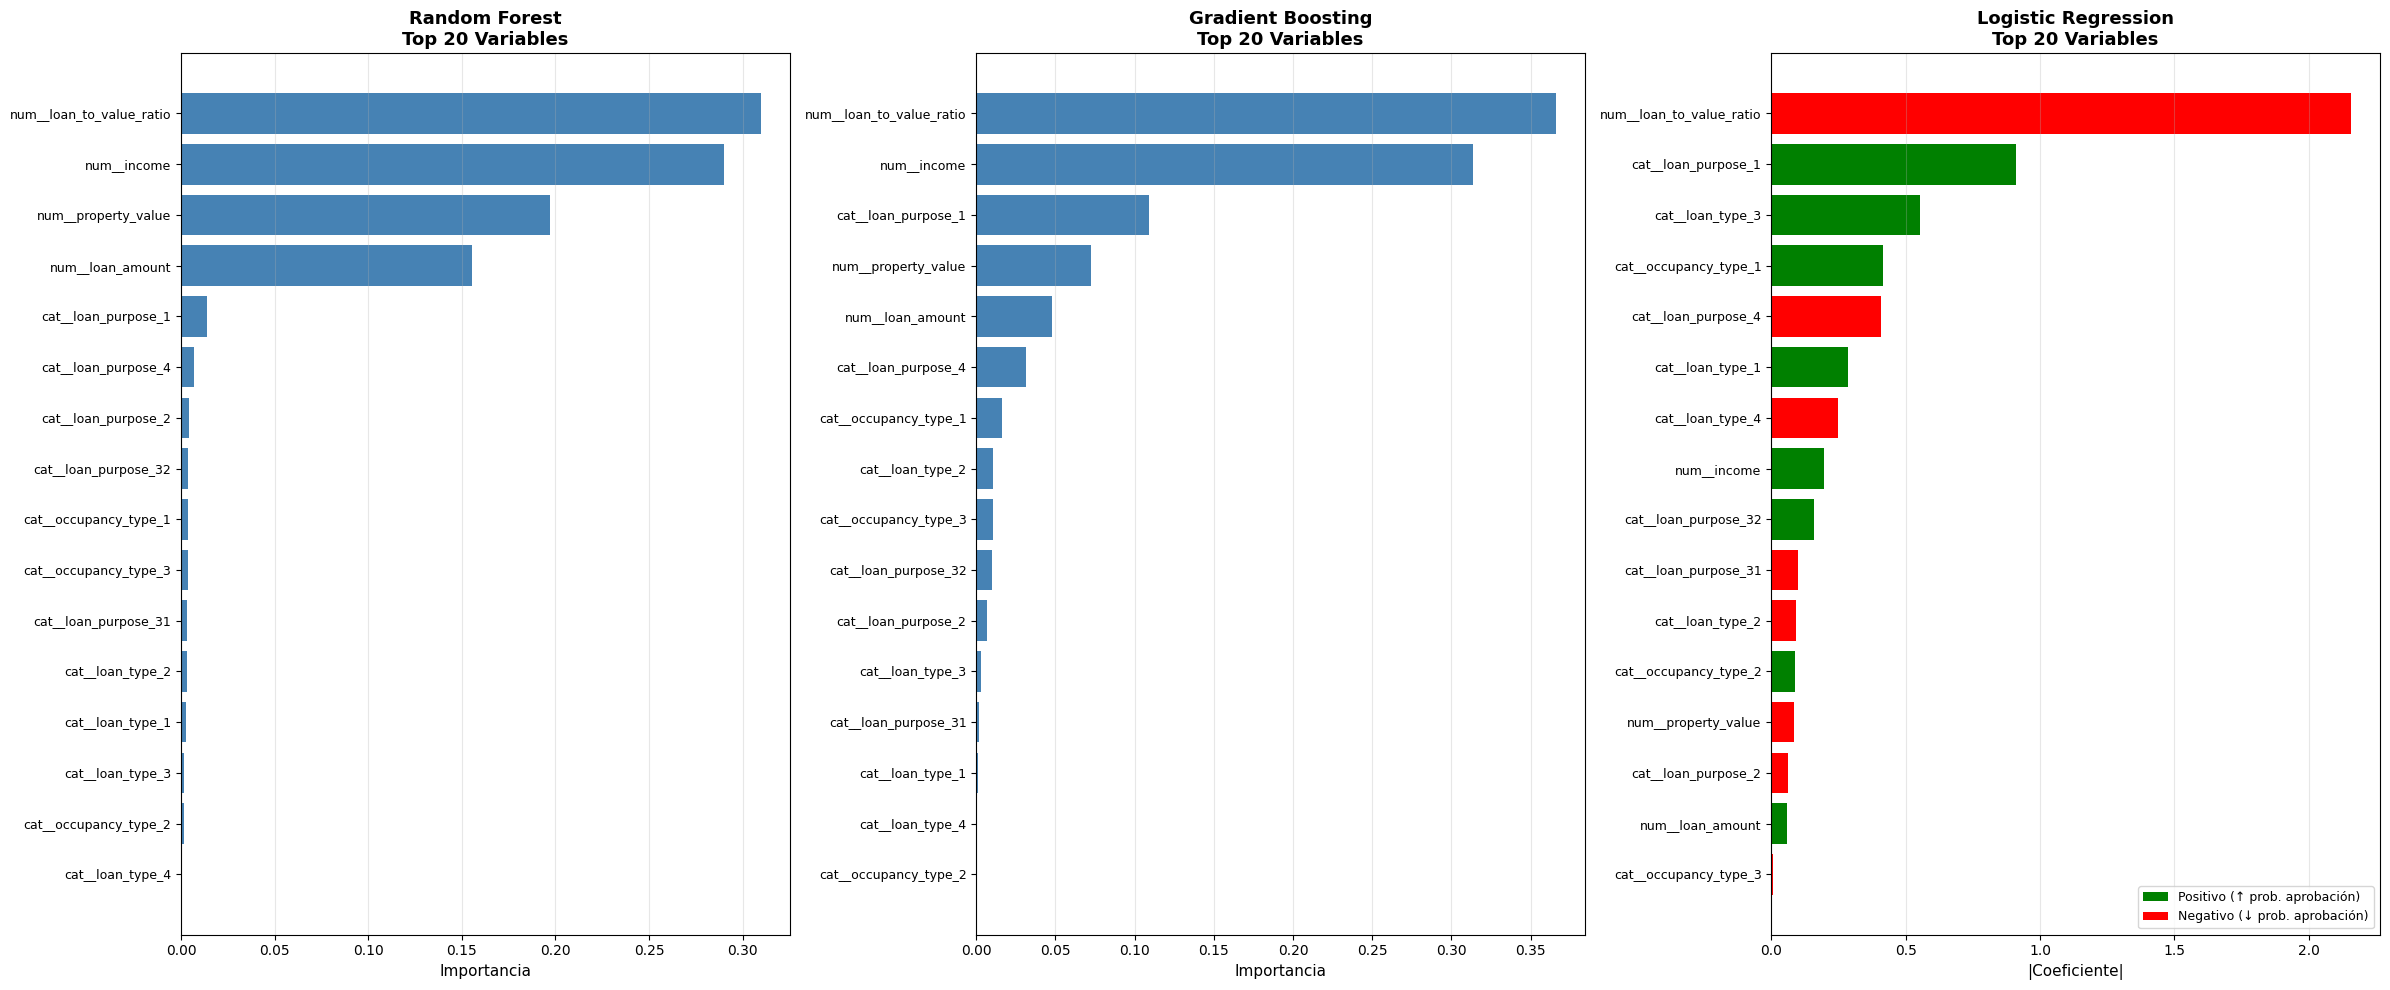


INTERPRETACIÓN DE RESULTADOS

    Random Forest y Gradient Boosting:
    - Importancia basada en reducción de impureza/ganancia
    - Valores más altos = mayor contribución a la predicción
    - Útil para identificar variables clave

    Regresión Logística:
    - Verde: coeficiente positivo (aumenta prob. de aprobación)
    - Rojo: coeficiente negativo (disminuye prob. de aprobación)
    - Magnitud = fuerza de la relación

    NOTA: Esta es una visión global. Para entender contribuciones 
    individuales, usar SHAP (sección 8.2) o LIME (sección 8.3).
    


In [5]:
# 8.1 Feature Importance: Análisis de la Importancia de Variables
# ================================================================

# Este análisis nos permite entender qué variables contribuyen más a las 
# predicciones del modelo y cómo lo hacen.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Diccionario para almacenar las importancias de cada modelo
feature_importances = {}

# ----------------------------------------------------------------------
# 8.1.1 Random Forest: Importancia basada en Impureza (Gini/Entropy)
# ----------------------------------------------------------------------
if 'rf_model' in locals() or 'rf_model' in globals():
    # Obtener nombres de features del pipeline (si usaste pipeline)
    # Si no usaste pipeline, reemplaza con la lista de nombres de columnas
    try:
        # Intentar obtener feature names del pipeline
        feature_names = rf_model.named_steps['preprocessor'].get_feature_names_out()
    except:
        # Si no hay pipeline, usar los nombres directamente
        # AJUSTA ESTO según tu caso específico
        feature_names = X_train.columns if hasattr(X_train, 'columns') else [f'feature_{i}' for i in range(len(rf_model.feature_importances_))]
    
    rf_importances = rf_model.named_steps['classifier'].feature_importances_ if hasattr(rf_model, 'named_steps') else rf_model.feature_importances_
    feature_importances['Random Forest'] = pd.DataFrame({
        'feature': feature_names,
        'importance': rf_importances
    }).sort_values('importance', ascending=False)
    
    print("=" * 70)
    print("RANDOM FOREST: Importancia de Variables (top 15)")
    print("=" * 70)
    print(feature_importances['Random Forest'].head(15).to_string(index=False))
    print()

# ----------------------------------------------------------------------
# 8.1.2 Gradient Boosting: Importancia basada en Ganancia de Split
# ----------------------------------------------------------------------
if 'gb_model' in locals() or 'gb_model' in globals():
    try:
        feature_names = gb_model.named_steps['preprocessor'].get_feature_names_out()
    except:
        feature_names = X_train.columns if hasattr(X_train, 'columns') else [f'feature_{i}' for i in range(len(gb_model.feature_importances_))]
    
    gb_importances = gb_model.named_steps['classifier'].feature_importances_ if hasattr(gb_model, 'named_steps') else gb_model.feature_importances_
    feature_importances['Gradient Boosting'] = pd.DataFrame({
        'feature': feature_names,
        'importance': gb_importances
    }).sort_values('importance', ascending=False)
    
    print("=" * 70)
    print("GRADIENT BOOSTING: Importancia de Variables (top 15)")
    print("=" * 70)
    print(feature_importances['Gradient Boosting'].head(15).to_string(index=False))
    print()

# ----------------------------------------------------------------------
# 8.1.3 Regresión Logística: Coeficientes (valor absoluto)
# ----------------------------------------------------------------------
if 'lr_model' in locals() or 'lr_model' in globals():
    try:
        feature_names = lr_model.named_steps['preprocessor'].get_feature_names_out()
    except:
        feature_names = X_train.columns if hasattr(X_train, 'columns') else [f'feature_{i}' for i in range(len(lr_model.coef_[0]))]
    
    lr_coefs = lr_model.named_steps['classifier'].coef_[0] if hasattr(lr_model, 'named_steps') else lr_model.coef_[0]
    feature_importances['Logistic Regression'] = pd.DataFrame({
        'feature': feature_names,
        'coefficient': lr_coefs,
        'abs_coefficient': np.abs(lr_coefs)
    }).sort_values('abs_coefficient', ascending=False)
    
    print("=" * 70)
    print("REGRESIÓN LOGÍSTICA: Coeficientes (top 15 por valor absoluto)")
    print("=" * 70)
    print(feature_importances['Logistic Regression'][['feature', 'coefficient', 'abs_coefficient']].head(15).to_string(index=False))
    print()

# ----------------------------------------------------------------------
# 8.1.4 Visualización Comparativa de Feature Importance
# ----------------------------------------------------------------------

# Determinar cuántas figuras crear según los modelos disponibles
n_models = len(feature_importances)

if n_models > 0:
    fig, axes = plt.subplots(1, n_models, figsize=(8*n_models, 10))
    if n_models == 1:
        axes = [axes]
    
    for idx, (model_name, importance_df) in enumerate(feature_importances.items()):
        ax = axes[idx]
        
        # Tomar top 20 features
        top_features = importance_df.head(20).copy()
        
        # Para regresión logística, usar valor absoluto
        if model_name == 'Logistic Regression':
            y_values = top_features['abs_coefficient']
            colors = ['green' if x > 0 else 'red' for x in top_features['coefficient']]
        else:
            y_values = top_features['importance']
            colors = 'steelblue'
        
        # Crear barplot horizontal
        ax.barh(range(len(top_features)), y_values, color=colors)
        ax.set_yticks(range(len(top_features)))
        ax.set_yticklabels(top_features['feature'], fontsize=9)
        ax.invert_yaxis()
        ax.set_xlabel('Importancia' if model_name != 'Logistic Regression' else '|Coeficiente|', fontsize=11)
        ax.set_title(f'{model_name}\nTop 20 Variables', fontsize=13, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
        
        # Añadir leyenda para regresión logística
        if model_name == 'Logistic Regression':
            from matplotlib.patches import Patch
            legend_elements = [
                Patch(facecolor='green', label='Positivo (↑ prob. aprobación)'),
                Patch(facecolor='red', label='Negativo (↓ prob. aprobación)')
            ]
            ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "=" * 70)
    print("INTERPRETACIÓN DE RESULTADOS")
    print("=" * 70)
    print("""
    Random Forest y Gradient Boosting:
    - Importancia basada en reducción de impureza/ganancia
    - Valores más altos = mayor contribución a la predicción
    - Útil para identificar variables clave
    
    Regresión Logística:
    - Verde: coeficiente positivo (aumenta prob. de aprobación)
    - Rojo: coeficiente negativo (disminuye prob. de aprobación)
    - Magnitud = fuerza de la relación
    
    NOTA: Esta es una visión global. Para entender contribuciones 
    individuales, usar SHAP (sección 8.2) o LIME (sección 8.3).
    """)
else:
    print("⚠️ No se encontraron modelos entrenados.")
    print("Asegúrate de que las variables se llamen: 'lr_model', 'rf_model', 'gb_model'")
    print("O ajusta el código según los nombres de tus modelos.")

### 8.2 Análisis SHAP (SHapley Additive exPlanations)

SHAP es un método de interpretabilidad que utiliza valores de Shapley de la teoría de juegos cooperativos para asignar una contribución a cada característica en la predicción del modelo.

**Ventajas de SHAP:**
- Proporciona explicaciones tanto globales como locales
- Es teóricamente sólido (basado en teoría de juegos)
- Permite entender interacciones entre variables

ANÁLISIS SHAP: Interpretabilidad Avanzada

1. Preparando datos para análisis SHAP...
   - Muestra: 500 observaciones
   - Features tras preprocesamiento: 16
   - Modelo seleccionado: RandomForestClassifier

2. Creando SHAP Explainer...
   ✓ Explainer creado: TreeExplainer
   ✓ SHAP values calculados

3. Generando Summary Plot (vista global)...


<Figure size 1200x800 with 0 Axes>

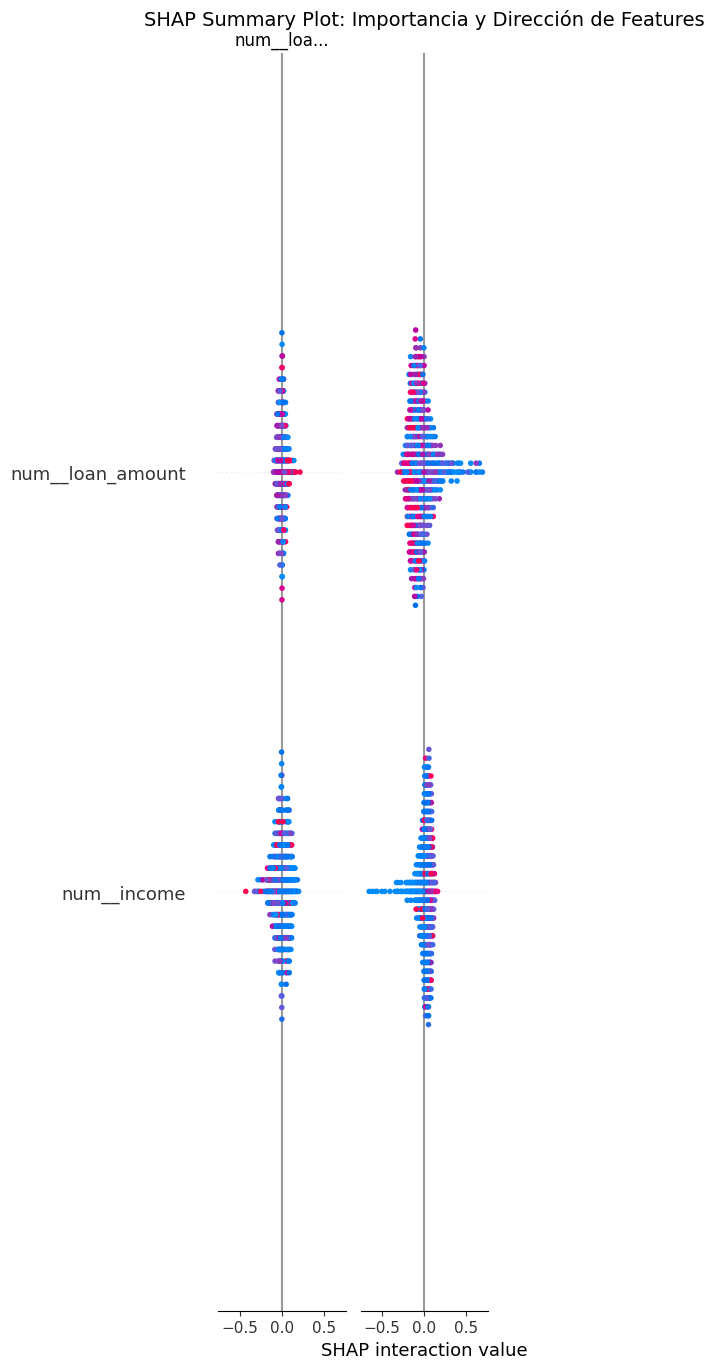


   CÓMO INTERPRETAR EL SUMMARY PLOT:
   - Eje Y: variables ordenadas por importancia (arriba = más importante)
   - Eje X: valor SHAP (impacto en la predicción)
   - Color: valor de la feature (rojo=alto, azul=bajo)
   - Dispersión horizontal: variabilidad del impacto según el valor

   Ejemplo: Si "income" está arriba y los puntos rojos (ingresos altos) 
   están a la derecha (SHAP positivo), significa que ingresos altos 
   aumentan la probabilidad de aprobación.


4. Generando Bar Plot (importancia promedio)...


<Figure size 1200x800 with 0 Axes>

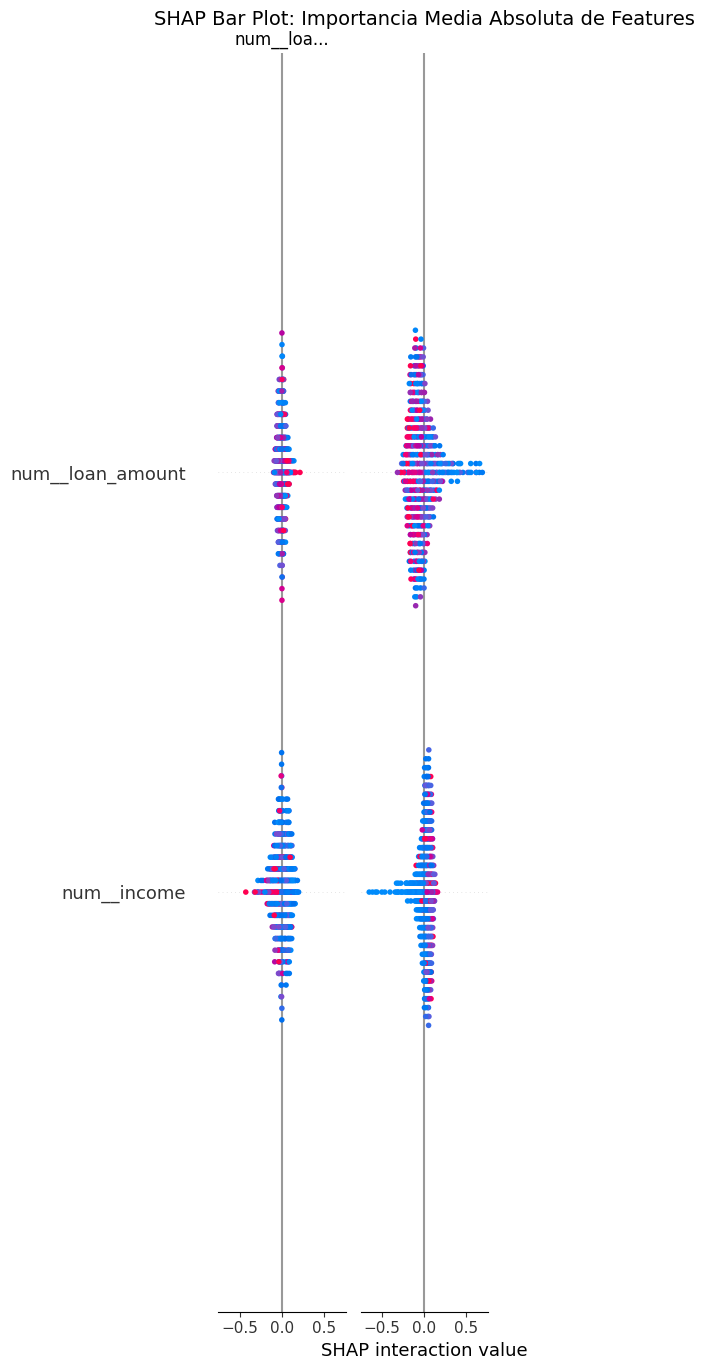

ValueError: Per-column arrays must each be 1-dimensional

In [6]:
# 8.2 Análisis SHAP: Explicaciones Locales y Globales del Modelo
# ================================================================

# SHAP (SHapley Additive exPlanations) proporciona valores de Shapley 
# para explicar la contribución de cada feature a las predicciones.

# Instalar shap si no está disponible (descomentar si es necesario)
# !pip install shap

import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Configurar para mejores visualizaciones
shap.initjs()

print("=" * 70)
print("ANÁLISIS SHAP: Interpretabilidad Avanzada")
print("=" * 70)

# ----------------------------------------------------------------------
# 8.2.1 Preparar datos para SHAP
# ----------------------------------------------------------------------
print("\n1. Preparando datos para análisis SHAP...")

# Usar una muestra para acelerar el cálculo (SHAP puede ser lento)
# Puedes ajustar el tamaño según tu capacidad computacional
SAMPLE_SIZE = min(500, len(X_test))
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), SAMPLE_SIZE, replace=False)
X_test_sample = X_test.iloc[sample_indices]
y_test_sample = y_test.iloc[sample_indices]

# Transformar los datos (aplicar solo el preprocesamiento)
# Extraer el transformador del pipeline
model_to_explain = rf_model  # Cambia a gb_model o lr_model según prefieras

# Obtener datos transformados
X_test_transformed = model_to_explain.named_steps['preprocessor'].transform(X_test_sample)
feature_names = model_to_explain.named_steps['preprocessor'].get_feature_names_out()

print(f"   - Muestra: {SAMPLE_SIZE} observaciones")
print(f"   - Features tras preprocesamiento: {X_test_transformed.shape[1]}")
print(f"   - Modelo seleccionado: {type(model_to_explain.named_steps['classifier']).__name__}")

# ----------------------------------------------------------------------
# 8.2.2 Crear el Explainer SHAP
# ----------------------------------------------------------------------
print("\n2. Creando SHAP Explainer...")

# Para modelos tree-based (Random Forest, Gradient Boosting)
if 'RandomForest' in str(type(model_to_explain.named_steps['classifier'])):
    explainer = shap.TreeExplainer(model_to_explain.named_steps['classifier'])
    shap_values = explainer.shap_values(X_test_transformed)
    
    # Para clasificación binaria, TreeExplainer devuelve lista [clase_0, clase_1]
    # Tomamos los valores de la clase positiva (aprobación)
    if isinstance(shap_values, list):
        shap_values_pos = shap_values[1]
    else:
        shap_values_pos = shap_values
        
elif 'GradientBoosting' in str(type(model_to_explain.named_steps['classifier'])):
    explainer = shap.TreeExplainer(model_to_explain.named_steps['classifier'])
    shap_values = explainer.shap_values(X_test_transformed)
    
    if isinstance(shap_values, list):
        shap_values_pos = shap_values[1]
    else:
        shap_values_pos = shap_values
        
else:  # Para Logistic Regression u otros modelos
    explainer = shap.LinearExplainer(model_to_explain.named_steps['classifier'], 
                                     X_test_transformed)
    shap_values_pos = explainer.shap_values(X_test_transformed)

print(f"   ✓ Explainer creado: {type(explainer).__name__}")
print(f"   ✓ SHAP values calculados")

# ----------------------------------------------------------------------
# 8.2.3 VISUALIZACIÓN 1: Summary Plot (Importancia Global)
# ----------------------------------------------------------------------
print("\n3. Generando Summary Plot (vista global)...")

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_pos, X_test_transformed, 
                  feature_names=feature_names, 
                  max_display=20,
                  show=False)
plt.title('SHAP Summary Plot: Importancia y Dirección de Features', 
          fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print("""
   CÓMO INTERPRETAR EL SUMMARY PLOT:
   - Eje Y: variables ordenadas por importancia (arriba = más importante)
   - Eje X: valor SHAP (impacto en la predicción)
   - Color: valor de la feature (rojo=alto, azul=bajo)
   - Dispersión horizontal: variabilidad del impacto según el valor
   
   Ejemplo: Si "income" está arriba y los puntos rojos (ingresos altos) 
   están a la derecha (SHAP positivo), significa que ingresos altos 
   aumentan la probabilidad de aprobación.
""")

# ----------------------------------------------------------------------
# 8.2.4 VISUALIZACIÓN 2: Bar Plot (Importancia Media Absoluta)
# ----------------------------------------------------------------------
print("\n4. Generando Bar Plot (importancia promedio)...")

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_pos, X_test_transformed, 
                  feature_names=feature_names,
                  plot_type="bar",
                  max_display=20,
                  show=False)
plt.title('SHAP Bar Plot: Importancia Media Absoluta de Features', 
          fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Calcular importancia media absoluta
mean_abs_shap = np.abs(shap_values_pos).mean(axis=0)
importance_df = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False)

print("\nTop 15 Features por Importancia SHAP:")
print(importance_df.head(15).to_string(index=False))

# ----------------------------------------------------------------------
# 8.2.5 VISUALIZACIÓN 3: Dependence Plots (Relaciones No Lineales)
# ----------------------------------------------------------------------
print("\n5. Generando Dependence Plots para variables clave...")

# Seleccionar top 4 features
top_features_indices = np.argsort(mean_abs_shap)[-4:][::-1]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, feature_idx in enumerate(top_features_indices):
    ax = axes[idx]
    shap.dependence_plot(feature_idx, shap_values_pos, X_test_transformed,
                         feature_names=feature_names,
                         ax=ax,
                         show=False)
    ax.set_title(f'Dependencia: {feature_names[feature_idx]}', fontsize=12)

plt.suptitle('SHAP Dependence Plots: Relación entre Valor y SHAP Value', 
             fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

print("""
   CÓMO INTERPRETAR DEPENDENCE PLOTS:
   - Eje X: valor de la feature
   - Eje Y: valor SHAP (impacto en predicción)
   - Color: interacción con otra feature
   
   Estos gráficos revelan:
   - Relaciones no lineales
   - Umbrales o puntos de inflexión
   - Interacciones entre variables
""")

# ----------------------------------------------------------------------
# 8.2.6 EXPLICACIONES LOCALES: Casos Específicos
# ----------------------------------------------------------------------
print("\n6. Analizando casos individuales (explicaciones locales)...")

# Seleccionar casos interesantes:
# - Un caso aprobado con alta confianza
# - Un caso denegado con alta confianza
# - Un caso cercano a la frontera de decisión

predictions_proba = model_to_explain.predict_proba(X_test_sample)[:, 1]

# Índices de casos interesantes
idx_high_approval = np.argmax(predictions_proba)  # Mayor prob. aprobación
idx_high_denial = np.argmin(predictions_proba)    # Mayor prob. denegación
idx_uncertain = np.argmin(np.abs(predictions_proba - 0.5))  # Más incierto

casos = {
    'Alta Probabilidad de Aprobación': idx_high_approval,
    'Alta Probabilidad de Denegación': idx_high_denial,
    'Caso Incierto (frontera decisión)': idx_uncertain
}

print("\nCasos seleccionados para análisis detallado:")
for nombre, idx in casos.items():
    prob = predictions_proba[idx]
    real = 'Aprobado' if y_test_sample.iloc[idx] == 1 else 'Denegado'
    print(f"   - {nombre}: prob={prob:.1%}, real={real}")

# ----------------------------------------------------------------------
# 8.2.7 VISUALIZACIÓN 4: Waterfall Plots (Explicación Local Detallada)
# ----------------------------------------------------------------------
print("\n7. Generando Waterfall Plots...")

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

for ax, (nombre, idx) in zip(axes, casos.items()):
    # Crear Explanation object para SHAP 0.42+
    explanation = shap.Explanation(
        values=shap_values_pos[idx],
        base_values=explainer.expected_value if hasattr(explainer, 'expected_value') else shap_values_pos.mean(),
        data=X_test_transformed[idx],
        feature_names=feature_names
    )
    
    shap.plots.waterfall(explanation, max_display=15, show=False)
    ax.set_title(f'{nombre}\nProb. Aprobación: {predictions_proba[idx]:.1%}', 
                 fontsize=11)

plt.tight_layout()
plt.show()

print("""
   CÓMO INTERPRETAR WATERFALL PLOTS:
   - Comienza en el valor base (predicción promedio del modelo)
   - Cada barra muestra cómo una feature empuja la predicción arriba o abajo
   - Rojo: aumenta probabilidad de aprobación
   - Azul: disminuye probabilidad de aprobación
   - El resultado final es f(x), la predicción para ese caso
""")

# ----------------------------------------------------------------------
# 8.2.8 VISUALIZACIÓN 5: Force Plot (Alternativa Visual)
# ----------------------------------------------------------------------
print("\n8. Generando Force Plot (explicación compacta)...")

# Force plot para el caso de alta aprobación
idx_explain = casos['Alta Probabilidad de Aprobación']

# Nota: force_plot funciona mejor en notebooks de Jupyter con JavaScript habilitado
# Aquí usamos matplotlib=True para renderizado estático
shap.force_plot(
    explainer.expected_value if hasattr(explainer, 'expected_value') else shap_values_pos.mean(),
    shap_values_pos[idx_explain],
    X_test_transformed[idx_explain],
    feature_names=feature_names,
    matplotlib=True,
    show=False,
    figsize=(20, 3)
)
plt.title(f'Force Plot: Caso con Alta Probabilidad de Aprobación ({predictions_proba[idx_explain]:.1%})', 
          fontsize=13, pad=10)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# 8.2.9 RESUMEN: Insights Principales
# ----------------------------------------------------------------------
print("\n" + "=" * 70)
print("PRINCIPALES INSIGHTS DEL ANÁLISIS SHAP")
print("=" * 70)

# Top 5 features más importantes
print("\n📊 TOP 5 FEATURES MÁS INFLUYENTES:")
for i, row in importance_df.head(5).iterrows():
    print(f"   {i+1}. {row['feature']}: {row['mean_abs_shap']:.4f}")

print("""
\n💡 VENTAJAS DE SHAP vs. FEATURE IMPORTANCE TRADICIONAL:
   ✓ Muestra dirección del impacto (positivo/negativo), no solo magnitud
   ✓ Revela relaciones no lineales y umbrales
   ✓ Proporciona explicaciones individuales (por qué se aprobó/denegó ESTE préstamo)
   ✓ Detecta interacciones entre variables
   ✓ Teóricamente fundamentado (valores de Shapley)

\n⚠️ CONSIDERACIONES ÉTICAS:
   - Si features relacionadas con raza/sexo/edad tienen alto SHAP, podría indicar sesgo
   - Analizar si las variables más importantes son justificables desde perspectiva ética
   - Usar estos insights para el análisis de fairness (Sección 9)
""")

### 8.3 Análisis LIME (Local Interpretable Model-agnostic Explanations)

LIME es una técnica que explica predicciones individuales aproximando localmente el modelo complejo con un modelo interpretable (generalmente lineal).

**Ventajas de LIME:**
- Es agnóstico al modelo (funciona con cualquier tipo de clasificador)
- Proporciona explicaciones intuitivas y fáciles de entender
- Útil para explicar predicciones específicas a usuarios no técnicos

In [ ]:
# 8.3 Análisis LIME: Explicaciones Locales Intuitivas
# ================================================================

# LIME (Local Interpretable Model-agnostic Explanations) explica predicciones
# individuales aproximando el modelo complejo localmente con un modelo lineal simple.

# Instalar lime si no está disponible (descomentar si es necesario)
# !pip install lime

import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("=" * 70)
print("ANÁLISIS LIME: Explicaciones Locales Interpretables")
print("=" * 70)

# ----------------------------------------------------------------------
# 8.3.1 Preparar el explainer LIME
# ----------------------------------------------------------------------
print("\n1. Configurando LIME Explainer...")

# Usar el mismo modelo que en SHAP (o cambiar según preferencia)
model_to_explain_lime = rf_model  # Cambia a gb_model o lr_model si prefieres

# Obtener datos transformados para todo el conjunto de entrenamiento
# LIME necesita conocer la distribución de los datos de entrenamiento
X_train_transformed = model_to_explain_lime.named_steps['preprocessor'].transform(X_train)
X_test_transformed_full = model_to_explain_lime.named_steps['preprocessor'].transform(X_test)

# Obtener nombres de features tras preprocesamiento
feature_names_lime = model_to_explain_lime.named_steps['preprocessor'].get_feature_names_out()

# Definir nombres de clases
class_names = ['Denegado', 'Aprobado']

# Crear el explainer LIME
# Usamos una muestra de entrenamiento para acelerar (LIME puede ser lento)
TRAIN_SAMPLE_SIZE = min(1000, len(X_train_transformed))
np.random.seed(42)
train_sample_indices = np.random.choice(len(X_train_transformed), TRAIN_SAMPLE_SIZE, replace=False)

explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_transformed[train_sample_indices],
    feature_names=feature_names_lime,
    class_names=class_names,
    mode='classification',
    discretize_continuous=True,
    random_state=42
)

print(f"   ✓ LIME Explainer configurado")
print(f"   - Modelo: {type(model_to_explain_lime.named_steps['classifier']).__name__}")
print(f"   - Features: {len(feature_names_lime)}")
print(f"   - Datos de entrenamiento para contexto: {TRAIN_SAMPLE_SIZE} muestras")

# ----------------------------------------------------------------------
# 8.3.2 Función auxiliar para generar predicciones
# ----------------------------------------------------------------------

def predict_proba_lime(X):
    """
    Función wrapper para que LIME pueda usar el modelo.
    LIME espera una función que tome un array numpy y devuelva probabilidades.
    """
    return model_to_explain_lime.named_steps['classifier'].predict_proba(X)

# ----------------------------------------------------------------------
# 8.3.3 Seleccionar casos interesantes para explicar
# ----------------------------------------------------------------------
print("\n2. Seleccionando casos representativos...")

# Obtener predicciones del modelo
predictions_proba = model_to_explain_lime.predict_proba(X_test)[:, 1]
predictions = model_to_explain_lime.predict(X_test)

# Seleccionar 6 casos variados:
# 1. True Positive (correctamente aprobado) - alta confianza
# 2. True Positive (correctamente aprobado) - baja confianza
# 3. True Negative (correctamente denegado) - alta confianza
# 4. True Negative (correctamente denegado) - baja confianza
# 5. False Positive (incorrectamente aprobado)
# 6. False Negative (incorrectamente denegado)

casos_lime = {}

# True Positives
tp_mask = (predictions == 1) & (y_test.values == 1)
tp_indices = np.where(tp_mask)[0]
if len(tp_indices) > 0:
    tp_probs = predictions_proba[tp_indices]
    casos_lime['TP Alta Confianza'] = tp_indices[np.argmax(tp_probs)]
    casos_lime['TP Baja Confianza'] = tp_indices[np.argmin(tp_probs)]

# True Negatives
tn_mask = (predictions == 0) & (y_test.values == 0)
tn_indices = np.where(tn_mask)[0]
if len(tn_indices) > 0:
    tn_probs = predictions_proba[tn_indices]
    casos_lime['TN Alta Confianza'] = tn_indices[np.argmin(tn_probs)]
    casos_lime['TN Baja Confianza'] = tn_indices[np.argmax(tn_probs)]

# False Positives
fp_mask = (predictions == 1) & (y_test.values == 0)
fp_indices = np.where(fp_mask)[0]
if len(fp_indices) > 0:
    casos_lime['False Positive'] = fp_indices[0]

# False Negatives
fn_mask = (predictions == 0) & (y_test.values == 1)
fn_indices = np.where(fn_mask)[0]
if len(fn_indices) > 0:
    casos_lime['False Negative'] = fn_indices[0]

print("\nCasos seleccionados:")
for nombre, idx in casos_lime.items():
    prob_aprobacion = predictions_proba[idx]
    pred = 'Aprobado' if predictions[idx] == 1 else 'Denegado'
    real = 'Aprobado' if y_test.iloc[idx] == 1 else 'Denegado'
    print(f"   - {nombre:20s}: Prob={prob_aprobacion:.1%}, Pred={pred}, Real={real}")

# ----------------------------------------------------------------------
# 8.3.4 Generar explicaciones LIME para cada caso
# ----------------------------------------------------------------------
print("\n3. Generando explicaciones LIME (esto puede tardar unos segundos)...")

lime_explanations = {}

for nombre, idx in casos_lime.items():
    # Explicar la instancia
    exp = explainer_lime.explain_instance(
        data_row=X_test_transformed_full[idx],
        predict_fn=predict_proba_lime,
        num_features=15,  # Top 15 features más importantes
        num_samples=500   # Número de perturbaciones (más = mejor pero más lento)
    )
    lime_explanations[nombre] = exp
    print(f"   ✓ {nombre}")

# ----------------------------------------------------------------------
# 8.3.5 VISUALIZACIÓN 1: Explicaciones individuales en subplots
# ----------------------------------------------------------------------
print("\n4. Visualizando explicaciones LIME...")

n_casos = len(lime_explanations)
fig, axes = plt.subplots(3, 2, figsize=(18, 16))
axes = axes.flatten()

for idx, (nombre, exp) in enumerate(lime_explanations.items()):
    if idx < len(axes):
        ax = axes[idx]
        
        # Obtener info del caso
        caso_idx = casos_lime[nombre]
        prob = predictions_proba[caso_idx]
        pred = 'Aprobado' if predictions[caso_idx] == 1 else 'Denegado'
        real = 'Aprobado' if y_test.iloc[caso_idx] == 1 else 'Denegado'
        
        # Obtener explicación para clase "Aprobado" (clase 1)
        exp_list = exp.as_list(label=1)
        
        # Extraer features y valores
        features = [item[0] for item in exp_list]
        values = [item[1] for item in exp_list]
        
        # Crear gráfico horizontal
        colors_bar = ['green' if v > 0 else 'red' for v in values]
        y_pos = np.arange(len(features))
        
        ax.barh(y_pos, values, color=colors_bar, alpha=0.7)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(features, fontsize=8)
        ax.invert_yaxis()
        ax.set_xlabel('Contribución a "Aprobado"', fontsize=9)
        ax.set_title(f'{nombre}\nPred: {pred} ({prob:.1%}) | Real: {real}', 
                     fontsize=10, fontweight='bold')
        ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
        ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("""
   CÓMO INTERPRETAR LOS GRÁFICOS:
   - Verde: aumenta la probabilidad de aprobación
   - Rojo: disminuye la probabilidad de aprobación
   - Longitud de barra: magnitud del efecto
   - Texto en Y: condición de la feature (ej: "income > 85.0")
""")

# ----------------------------------------------------------------------
# 8.3.6 VISUALIZACIÓN 2: Explicación detallada de un caso específico
# ----------------------------------------------------------------------
print("\n5. Análisis detallado de un caso específico...")

# Elegir un caso interesante (por ejemplo, False Positive si existe)
if 'False Positive' in lime_explanations:
    caso_detallado_nombre = 'False Positive'
elif 'TP Alta Confianza' in lime_explanations:
    caso_detallado_nombre = 'TP Alta Confianza'
else:
    caso_detallado_nombre = list(lime_explanations.keys())[0]

exp_detallada = lime_explanations[caso_detallado_nombre]
caso_detallado_idx = casos_lime[caso_detallado_nombre]

print(f"\nCaso seleccionado: {caso_detallado_nombre}")
print(f"Probabilidad de aprobación: {predictions_proba[caso_detallado_idx]:.1%}")
print(f"Predicción: {'Aprobado' if predictions[caso_detallado_idx] == 1 else 'Denegado'}")
print(f"Valor real: {'Aprobado' if y_test.iloc[caso_detallado_idx] == 1 else 'Denegado'}")

# Mostrar tabla de explicación
exp_df = pd.DataFrame(exp_detallada.as_list(label=1), columns=['Feature', 'Contribución'])
exp_df['Efecto'] = exp_df['Contribución'].apply(lambda x: '↑ Aprobación' if x > 0 else '↓ Aprobación')

print("\n" + "=" * 80)
print("TOP 15 FEATURES MÁS INFLUYENTES EN ESTA PREDICCIÓN:")
print("=" * 80)
print(exp_df.to_string(index=False))

# ----------------------------------------------------------------------
# 8.3.7 Visualización HTML interactiva (opcional, para notebooks)
# ----------------------------------------------------------------------
print("\n6. Generando visualización HTML interactiva...")

# LIME puede generar una visualización HTML muy detallada
# Esto funciona mejor en Jupyter notebooks con display HTML habilitado
# Guardamos el HTML en una figura matplotlib para compatibilidad

fig, ax = plt.subplots(figsize=(16, 10))
ax.axis('off')

# Crear texto explicativo
texto_explicacion = f"""
EXPLICACIÓN LIME DETALLADA - {caso_detallado_nombre}
{'=' * 70}

Probabilidad de Aprobación: {predictions_proba[caso_detallado_idx]:.1%}
Predicción del Modelo: {'Aprobado' if predictions[caso_detallado_idx] == 1 else 'Denegado'}
Valor Real: {'Aprobado' if y_test.iloc[caso_detallado_idx] == 1 else 'Denegado'}

FEATURES QUE APOYAN LA APROBACIÓN (verde):
"""

# Agregar features positivas
for feat, contrib in exp_df[exp_df['Contribución'] > 0].head(5).values:
    texto_explicacion += f"\n  ✓ {feat}: +{contrib:.3f}"

texto_explicacion += f"\n\nFEATURES QUE APOYAN LA DENEGACIÓN (rojo):"

# Agregar features negativas
for feat, contrib in exp_df[exp_df['Contribución'] < 0].head(5).values:
    texto_explicacion += f"\n  ✗ {feat}: {contrib:.3f}"

ax.text(0.05, 0.95, texto_explicacion, transform=ax.transAxes, 
        fontsize=11, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# 8.3.8 Comparación: LIME vs Feature Importance Global
# ----------------------------------------------------------------------
print("\n7. Comparación con Feature Importance global...")

# Calcular frecuencia de aparición de cada feature en las explicaciones LIME
feature_frequency = {}

for nombre, exp in lime_explanations.items():
    for feat, _ in exp.as_list(label=1):
        # Extraer nombre base de la feature (antes del operador de comparación)
        feat_base = feat.split()[0] if ' ' in feat else feat
        feature_frequency[feat_base] = feature_frequency.get(feat_base, 0) + 1

# Ordenar por frecuencia
feature_freq_df = pd.DataFrame(
    list(feature_frequency.items()), 
    columns=['Feature', 'Frecuencia']
).sort_values('Frecuencia', ascending=False)

print("\nFeatures que aparecen más frecuentemente en explicaciones LIME:")
print(feature_freq_df.head(15).to_string(index=False))

# ----------------------------------------------------------------------
# 8.3.9 RESUMEN: Insights y Comparación con SHAP
# ----------------------------------------------------------------------
print("\n" + "=" * 70)
print("PRINCIPALES INSIGHTS DEL ANÁLISIS LIME")
print("=" * 70)

print(f"""
📊 CASOS ANALIZADOS: {len(lime_explanations)}
   - {sum(1 for k in casos_lime.keys() if 'TP' in k)} True Positives
   - {sum(1 for k in casos_lime.keys() if 'TN' in k)} True Negatives  
   - {sum(1 for k in casos_lime.keys() if 'FP' in k)} False Positives
   - {sum(1 for k in casos_lime.keys() if 'FN' in k)} False Negatives

💡 VENTAJAS DE LIME:
   ✓ Explicaciones muy intuitivas y fáciles de comunicar
   ✓ Muestra condiciones específicas (ej: "income > 85.0")
   ✓ Agnóstico al modelo (funciona con cualquier clasificador)
   ✓ Ideal para explicar decisiones a usuarios no técnicos

⚖️ LIME vs SHAP:
   - LIME: rápido, local, aproximación lineal, fácil de entender
   - SHAP: más lento, fundamentado teóricamente, valores exactos
   - LIME: mejor para casos individuales y comunicación
   - SHAP: mejor para entender el modelo globalmente

🎯 USO RECOMENDADO:
   - Usa LIME para explicar predicciones específicas a clientes
   - Usa SHAP para análisis profundo del comportamiento del modelo
   - Combina ambos para una interpretabilidad completa

⚠️ CONSIDERACIONES ÉTICAS:
   - Si explicaciones muestran dependencia de atributos sensibles → revisar
   - LIME es especialmente útil para auditorías de casos individuales
   - Permite detectar decisiones potencialmente injustas o discriminatorias
""")

print("\n" + "=" * 70)
print("ANÁLISIS LIME COMPLETADO")
print("=" * 70)

### 8.4 Coeficientes de regresión logística

In [ ]:
# 8.4 Análisis de Coeficientes de Regresión Logística
# ================================================================

# La Regresión Logística es especialmente interpretable porque sus coeficientes
# tienen un significado directo: representan el cambio en el log-odds (logaritmo
# de las probabilidades) de la variable objetivo por cada unidad de cambio en la feature.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

print("=" * 70)
print("ANÁLISIS DE COEFICIENTES: REGRESIÓN LOGÍSTICA")
print("=" * 70)

# Verificar que el modelo de regresión logística esté disponible
if 'lr_model' not in locals() and 'lr_model' not in globals():
    print("\n⚠️ ERROR: Modelo de regresión logística no encontrado.")
    print("Ejecuta primero las secciones de entrenamiento de modelos.")
else:
    
    # ----------------------------------------------------------------------
    # 8.4.1 Extraer coeficientes del modelo
    # ----------------------------------------------------------------------
    print("\n1. Extrayendo coeficientes del modelo...")
    
    # Obtener coeficientes y nombres de features
    coefficients = lr_model.named_steps['classifier'].coef_[0]
    feature_names_lr = lr_model.named_steps['preprocessor'].get_feature_names_out()
    intercept = lr_model.named_steps['classifier'].intercept_[0]
    
    print(f"   - Total de coeficientes: {len(coefficients)}")
    print(f"   - Intercepto (β₀): {intercept:.4f}")
    
    # Crear DataFrame con coeficientes
    coef_df = pd.DataFrame({
        'feature': feature_names_lr,
        'coefficient': coefficients,
        'abs_coefficient': np.abs(coefficients),
        'effect': ['Positivo (↑ prob. aprobación)' if c > 0 else 'Negativo (↓ prob. aprobación)' 
                   for c in coefficients]
    }).sort_values('abs_coefficient', ascending=False)
    
    # ----------------------------------------------------------------------
    # 8.4.2 Convertir coeficientes a Odds Ratios
    # ----------------------------------------------------------------------
    print("\n2. Calculando Odds Ratios...")
    
    # Odds Ratio = exp(β)
    # Interpreta: por cada unidad de aumento en X, las odds se multiplican por exp(β)
    coef_df['odds_ratio'] = np.exp(coef_df['coefficient'])
    coef_df['odds_ratio_interpretation'] = coef_df['odds_ratio'].apply(
        lambda x: f"×{x:.2f}" if x >= 1 else f"÷{1/x:.2f}"
    )
    
    print("""
    INTERPRETACIÓN DE ODDS RATIOS:
    - Odds Ratio > 1: aumenta las probabilidades de aprobación
    - Odds Ratio < 1: disminuye las probabilidades de aprobación
    - Odds Ratio = 1: no tiene efecto
    - Ejemplo: OR = 2.5 significa que las odds se multiplican por 2.5
    """)
    
    # ----------------------------------------------------------------------
    # 8.4.3 Top Features por Impacto
    # ----------------------------------------------------------------------
    print("\n3. Identificando features más influyentes...")
    
    print("\n" + "=" * 90)
    print("TOP 20 FEATURES CON MAYOR IMPACTO (por coeficiente absoluto)")
    print("=" * 90)
    print(coef_df[['feature', 'coefficient', 'odds_ratio', 'odds_ratio_interpretation', 'effect']].head(20).to_string(index=False))
    
    # Separar en positivos y negativos
    coef_positivos = coef_df[coef_df['coefficient'] > 0].sort_values('coefficient', ascending=False)
    coef_negativos = coef_df[coef_df['coefficient'] < 0].sort_values('coefficient', ascending=True)
    
    print("\n" + "=" * 90)
    print("TOP 10 FEATURES QUE MÁS AUMENTAN LA PROBABILIDAD DE APROBACIÓN")
    print("=" * 90)
    print(coef_positivos[['feature', 'coefficient', 'odds_ratio']].head(10).to_string(index=False))
    
    print("\n" + "=" * 90)
    print("TOP 10 FEATURES QUE MÁS DISMINUYEN LA PROBABILIDAD DE APROBACIÓN")
    print("=" * 90)
    print(coef_negativos[['feature', 'coefficient', 'odds_ratio']].head(10).to_string(index=False))
    
    # ----------------------------------------------------------------------
    # 8.4.4 VISUALIZACIÓN 1: Barplot de coeficientes
    # ----------------------------------------------------------------------
    print("\n4. Generando visualizaciones...")
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    
    # Subplot 1: Top 30 coeficientes por valor absoluto
    ax1 = axes[0]
    top_30 = coef_df.head(30).copy()
    colors = ['green' if c > 0 else 'red' for c in top_30['coefficient']]
    
    y_pos = np.arange(len(top_30))
    ax1.barh(y_pos, top_30['coefficient'], color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(top_30['feature'], fontsize=8)
    ax1.invert_yaxis()
    ax1.set_xlabel('Coeficiente (β)', fontsize=12, fontweight='bold')
    ax1.set_title('Top 30 Features por Magnitud de Coeficiente\n(Verde=Positivo, Rojo=Negativo)', 
                  fontsize=13, fontweight='bold', pad=15)
    ax1.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
    ax1.grid(axis='x', alpha=0.3, linestyle='--')
    
    # Añadir leyenda
    legend_elements = [
        Patch(facecolor='green', alpha=0.7, label='Aumenta prob. de aprobación'),
        Patch(facecolor='red', alpha=0.7, label='Disminuye prob. de aprobación')
    ]
    ax1.legend(handles=legend_elements, loc='lower right', fontsize=10)
    
    # Subplot 2: Top 30 por Odds Ratio
    ax2 = axes[1]
    
    # Separar en features con OR > 1 y OR < 1
    top_30_or = coef_df.head(30).copy()
    
    # Transformar para mejor visualización: log2(OR)
    # Esto hace simétrica la visualización
    top_30_or['log2_or'] = np.log2(top_30_or['odds_ratio'])
    colors_or = ['green' if x > 0 else 'red' for x in top_30_or['log2_or']]
    
    y_pos = np.arange(len(top_30_or))
    ax2.barh(y_pos, top_30_or['log2_or'], color=colors_or, alpha=0.7, edgecolor='black', linewidth=0.5)
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(top_30_or['feature'], fontsize=8)
    ax2.invert_yaxis()
    ax2.set_xlabel('Log₂(Odds Ratio)', fontsize=12, fontweight='bold')
    ax2.set_title('Top 30 Features por Odds Ratio\n(OR > 1 = aumenta odds, OR < 1 = disminuye odds)', 
                  fontsize=13, fontweight='bold', pad=15)
    ax2.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
    ax2.grid(axis='x', alpha=0.3, linestyle='--')
    
    # Añadir marcas de referencia
    ax2.axvline(x=1, color='gray', linestyle=':', alpha=0.5, label='OR = 2 (double odds)')
    ax2.axvline(x=-1, color='gray', linestyle=':', alpha=0.5, label='OR = 0.5 (half odds)')
    
    plt.tight_layout()
    plt.show()
    
    # ----------------------------------------------------------------------
    # 8.4.5 VISUALIZACIÓN 2: Distribución de coeficientes
    # ----------------------------------------------------------------------
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Histograma de coeficientes
    ax1 = axes[0, 0]
    ax1.hist(coef_df['coefficient'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Coef = 0')
    ax1.set_xlabel('Valor del Coeficiente', fontsize=11)
    ax1.set_ylabel('Frecuencia', fontsize=11)
    ax1.set_title('Distribución de Coeficientes', fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # Histograma de coeficientes absolutos
    ax2 = axes[0, 1]
    ax2.hist(coef_df['abs_coefficient'], bins=50, color='coral', edgecolor='black', alpha=0.7)
    ax2.set_xlabel('Valor Absoluto del Coeficiente', fontsize=11)
    ax2.set_ylabel('Frecuencia', fontsize=11)
    ax2.set_title('Distribución de Magnitudes (|Coeficiente|)', fontsize=12, fontweight='bold')
    ax2.set_yscale('log')
    ax2.grid(alpha=0.3)
    
    # Scatter: Coeficiente vs Odds Ratio
    ax3 = axes[1, 0]
    scatter = ax3.scatter(coef_df['coefficient'], coef_df['odds_ratio'], 
                          c=coef_df['coefficient'], cmap='RdYlGn', 
                          alpha=0.6, s=30, edgecolor='black', linewidth=0.3)
    ax3.axvline(x=0, color='black', linestyle='-', linewidth=1)
    ax3.axhline(y=1, color='black', linestyle='-', linewidth=1)
    ax3.set_xlabel('Coeficiente (β)', fontsize=11)
    ax3.set_ylabel('Odds Ratio (exp(β))', fontsize=11)
    ax3.set_title('Relación entre Coeficiente y Odds Ratio', fontsize=12, fontweight='bold')
    ax3.set_yscale('log')
    ax3.grid(alpha=0.3)
    plt.colorbar(scatter, ax=ax3, label='Coeficiente')
    
    # Conteo de efectos positivos vs negativos
    ax4 = axes[1, 1]
    counts = coef_df['effect'].value_counts()
    colors_pie = ['green', 'red']
    wedges, texts, autotexts = ax4.pie(counts, labels=counts.index, autopct='%1.1f%%', 
                                        colors=colors_pie, startangle=90,
                                        textprops={'fontsize': 10, 'weight': 'bold'})
    ax4.set_title('Proporción de Features:\nPositivos vs Negativos', 
                  fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # ----------------------------------------------------------------------
    # 8.4.6 Análisis de significancia estadística (opcional)
    # ----------------------------------------------------------------------
    print("\n5. Análisis de magnitud de coeficientes...")
    
    # Identificar coeficientes "sustanciales" (|β| > umbral)
    umbral_bajo = 0.1
    umbral_medio = 0.5
    umbral_alto = 1.0
    
    n_bajo = len(coef_df[coef_df['abs_coefficient'] < umbral_bajo])
    n_medio = len(coef_df[(coef_df['abs_coefficient'] >= umbral_bajo) & 
                          (coef_df['abs_coefficient'] < umbral_medio)])
    n_alto = len(coef_df[(coef_df['abs_coefficient'] >= umbral_medio) & 
                         (coef_df['abs_coefficient'] < umbral_alto)])
    n_muy_alto = len(coef_df[coef_df['abs_coefficient'] >= umbral_alto])
    
    print(f"""
    CLASIFICACIÓN POR MAGNITUD DEL IMPACTO:
    
    Impacto Bajo     (|β| < {umbral_bajo}):    {n_bajo:4d} features ({n_bajo/len(coef_df)*100:.1f}%)
    Impacto Moderado (|β| < {umbral_medio}):    {n_medio:4d} features ({n_medio/len(coef_df)*100:.1f}%)
    Impacto Alto     (|β| < {umbral_alto}):    {n_alto:4d} features ({n_alto/len(coef_df)*100:.1f}%)
    Impacto Muy Alto (|β| ≥ {umbral_alto}):    {n_muy_alto:4d} features ({n_muy_alto/len(coef_df)*100:.1f}%)
    """)
    
    # ----------------------------------------------------------------------
    # 8.4.7 RESUMEN: Insights e Interpretación
    # ----------------------------------------------------------------------
    print("\n" + "=" * 70)
    print("PRINCIPALES INSIGHTS DE REGRESIÓN LOGÍSTICA")
    print("=" * 70)
    
    # Feature más influyente positiva y negativa
    feat_mas_positivo = coef_positivos.iloc[0]
    feat_mas_negativo = coef_negativos.iloc[0]
    
    print(f"""
    📈 FEATURE MÁS INFLUYENTE (POSITIVA):
       - Nombre: {feat_mas_positivo['feature']}
       - Coeficiente: {feat_mas_positivo['coefficient']:.4f}
       - Odds Ratio: {feat_mas_positivo['odds_ratio']:.2f}
       - Interpretación: Por cada unidad de aumento, las odds de aprobación
         se multiplican por {feat_mas_positivo['odds_ratio']:.2f}
    
    📉 FEATURE MÁS INFLUYENTE (NEGATIVA):
       - Nombre: {feat_mas_negativo['feature']}
       - Coeficiente: {feat_mas_negativo['coefficient']:.4f}
       - Odds Ratio: {feat_mas_negativo['odds_ratio']:.2f}
       - Interpretación: Por cada unidad de aumento, las odds de aprobación
         se dividen por {1/feat_mas_negativo['odds_ratio']:.2f}
    
    🎯 VENTAJAS DE REGRESIÓN LOGÍSTICA:
       ✓ Interpretabilidad directa: coeficientes tienen significado claro
       ✓ Odds Ratios facilitan comunicación a audiencias no técnicas
       ✓ Permite identificar relaciones causales (con cuidado)
       ✓ Útil para cumplimiento regulatorio (explicabilidad)
    
    ⚖️ COMPARACIÓN CON OTROS MÉTODOS DE INTERPRETABILIDAD:
       - Coeficientes: efecto lineal promedio global
       - Feature Importance (RF/GB): importancia no paramétrica, no lineal
       - SHAP: contribuciones individuales, captura no linealidad
       - LIME: aproximación local, específica por instancia
    
    ⚠️ CONSIDERACIONES ÉTICAS:
       - Revisar si features relacionadas con atributos sensibles tienen
         coeficientes sustanciales → posible sesgo del modelo
       - Coeficientes deben tener justificación de negocio razonable
       - Si un coeficiente contradice la lógica del dominio → investigar
    
    💡 RECOMENDACIONES:
       - Usar coeficientes para comunicar resultados a stakeholders
       - Complementar con SHAP para casos no lineales
       - Validar que coeficientes sean estables en diferentes muestras
    """)
    
    print("\n" + "=" * 70)
    print("ANÁLISIS DE COEFICIENTES COMPLETADO")
    print("=" * 70)

## 9. Análisis ético y detección de sesgos

### 9.1 Análisis de tasas de aprobación por subgrupos

### 9.2 Análisis de rendimiento del modelo por subgrupos

### 9.3 Discusión sobre fuentes de sesgo

### 9.4 Implicaciones éticas

## 10. Análisis de Clustering: Segmentación de Solicitantes de Hipotecas

### ¿Por qué incluir clustering en un proyecto de clasificación supervisada?

Hasta este punto del proyecto, hemos trabajado exclusivamente con **aprendizaje supervisado**: teníamos una variable objetivo (`action_taken` → aprobado/denegado) y hemos entrenado modelos para predecirla. Sin embargo, el **aprendizaje no supervisado** —y en particular el **clustering**— aporta una perspectiva complementaria enormemente valiosa.

El clustering nos permite **descubrir patrones y agrupaciones naturales** en los datos de solicitantes **sin usar la etiqueta de aprobación**. Esto es útil por varias razones:

1. **Perfilado de solicitantes**: ¿Existen grupos naturales de solicitantes con características similares (ingresos, montos de préstamo, ratios de deuda)? Identificar estos perfiles ayuda a entender la composición del mercado hipotecario de Utah.

2. **Detección de anomalías**: Algoritmos como DBSCAN pueden identificar solicitudes atípicas que no encajan en ningún perfil habitual. Estas solicitudes podrían representar casos de fraude, errores de datos o simplemente situaciones inusuales que merecen revisión manual.

3. **Complemento al análisis ético**: Al cruzar los clusters descubiertos con atributos sensibles (raza, sexo, edad), podemos detectar si ciertos grupos demográficos se concentran desproporcionadamente en perfiles de mayor riesgo, lo que podría revelar **inequidades estructurales** en el acceso a la vivienda.

4. **Validación del modelo supervisado**: Comparar las agrupaciones naturales con las decisiones de aprobación/denegación nos permite evaluar si el modelo supervisado está capturando la estructura real de los datos o si hay discrepancias importantes.

### Algoritmos que utilizaremos

| Algoritmo | Ventaja principal | Limitación principal |
|-----------|------------------|---------------------|
| **K-Means** | Simple, rápido, escalable | Requiere especificar K; asume clusters esféricos |
| **DBSCAN** | Detecta formas arbitrarias y outliers; no requiere K | Sensible a la elección de `eps` y `min_samples` |
| **Clustering Jerárquico** | Proporciona dendrograma para visualizar la jerarquía | No escala bien a datasets muy grandes |

> **Referencia**: los conceptos y técnicas de esta sección se basan en las sesiones 17 (K-Means y variaciones) y 18 (DBSCAN, GMM, Clustering Jerárquico) del curso.

### 10.1 Preparación de Datos para Clustering

Antes de aplicar cualquier algoritmo de clustering, necesitamos:

1. **Seleccionar las variables numéricas relevantes** para la segmentación. Usaremos variables que describan el perfil financiero del solicitante y las características del préstamo:
   - `loan_amount`: monto del préstamo solicitado
   - `income`: ingresos anuales del solicitante
   - `property_value`: valor de la propiedad
   - `loan_to_value_ratio`: ratio préstamo/valor
   - `debt_to_income_ratio`: ratio deuda/ingresos (si es numérico)

2. **Escalar los datos con `StandardScaler`**: los algoritmos basados en distancia (K-Means, DBSCAN) son muy sensibles a la escala de las variables. Si no escalamos, una variable como `loan_amount` (con valores en decenas/centenas de miles) dominaría sobre `loan_to_value_ratio` (valores entre 0 y 1).

3. **Tratar valores faltantes**: eliminar o imputar NaN en las columnas seleccionadas antes del escalado.

> ⚠️ **Importante**: No incluimos la variable objetivo (`approved`) ni los atributos sensibles (`derived_race`, `derived_sex`, `applicant_age`) como features de clustering. Estos se analizarán *a posteriori* para interpretar los clusters.

In [ ]:
# 10.1 Preparación de datos para clustering
# ============================================

# 1. Seleccionar las variables numéricas relevantes para clustering
# clustering_features = ['loan_amount', 'income', 'property_value', 'loan_to_value_ratio']
# X_clustering = df[clustering_features].copy()

# 2. Eliminar filas con valores faltantes en estas columnas
# X_clustering = X_clustering.dropna()
# print(f"Registros disponibles para clustering: {len(X_clustering)}")
# print(X_clustering.describe())

# 3. Escalar los datos con StandardScaler
# from sklearn.preprocessing import StandardScaler
# scaler_clustering = StandardScaler()
# X_scaled = scaler_clustering.fit_transform(X_clustering)
# print(f"\nDatos escalados - shape: {X_scaled.shape}")

### 10.2 K-Means: Segmentación de Perfiles de Solicitantes

#### 10.2.1 Selección del número óptimo de clusters (K)

Para determinar el número adecuado de clusters, utilizamos dos métodos complementarios:

1. **Método del Codo (Elbow Method)**: ejecutamos K-Means para K = 2 hasta K = 10 y graficamos la **inercia** (suma de distancias al cuadrado de cada punto a su centroide). Buscamos el punto de inflexión donde añadir más clusters deja de reducir significativamente la inercia.

2. **Silhouette Score**: mide qué tan bien definidos están los clusters. Un valor cercano a 1 indica clusters bien separados; cercano a 0 indica solapamiento; negativo indica asignaciones incorrectas. Elegimos el K que maximice este score.

> 💡 **Tip**: No existe un K "perfecto". Los dos métodos nos dan orientación, pero la interpretabilidad de los clusters resultantes también es un criterio importante.

In [ ]:
# 10.2.1 Método del Codo y Silhouette Score
# ============================================

# from sklearn.cluster import KMeans
# from sklearn.metrics import silhouette_score
# import matplotlib.pyplot as plt
# import numpy as np

# inertias = []
# silhouette_scores = []
# K_range = range(2, 11)

# for k in K_range:
#     kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
#     kmeans_temp.fit(X_scaled)
#     inertias.append(kmeans_temp.inertia_)
#     silhouette_scores.append(silhouette_score(X_scaled, kmeans_temp.labels_))

# # Gráfico combinado: Método del Codo + Silhouette Score
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# # Método del Codo
# ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
# ax1.set_xlabel('Número de Clusters (K)')
# ax1.set_ylabel('Inercia')
# ax1.set_title('Método del Codo')
# ax1.set_xticks(list(K_range))
# ax1.grid(True, alpha=0.3)

# # Silhouette Score
# ax2.plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
# ax2.set_xlabel('Número de Clusters (K)')
# ax2.set_ylabel('Silhouette Score')
# ax2.set_title('Silhouette Score por K')
# ax2.set_xticks(list(K_range))
# ax2.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# # Imprimir valores
# print("K | Inercia      | Silhouette Score")
# print("-" * 40)
# for k, inertia, sil in zip(K_range, inertias, silhouette_scores):
#     print(f"{k} | {inertia:>12.2f} | {sil:.4f}")

#### 10.2.2 Entrenamiento de K-Means con K óptimo

Una vez seleccionado el valor de K según los métodos anteriores, entrenamos el modelo definitivo y asignamos cada solicitante a un cluster.

**Tareas:**
- Entrenar `KMeans` con el K elegido
- Añadir la columna `cluster` al DataFrame original
- Verificar la distribución de solicitantes por cluster

In [ ]:
# 10.2.2 Entrenamiento de K-Means con K óptimo
# ============================================

# K_OPTIMO = ...  # Elegir según los gráficos anteriores (ej. 4 o 5)

# kmeans_final = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10)
# clusters = kmeans_final.fit_predict(X_scaled)

# # Añadir etiqueta de cluster al DataFrame
# df_clustering = X_clustering.copy()
# df_clustering['cluster'] = clusters

# # Distribución de solicitantes por cluster
# print("Distribución de solicitantes por cluster:")
# print(df_clustering['cluster'].value_counts().sort_index())
# print(f"\nSilhouette Score final: {silhouette_score(X_scaled, clusters):.4f}")

#### 10.2.3 Visualización de Clusters con PCA

Como nuestros datos tienen más de 2 dimensiones, necesitamos una técnica de **reducción de dimensionalidad** para poder visualizar los clusters en un plano 2D. Utilizamos **PCA (Principal Component Analysis)**, que proyecta los datos sobre los 2 componentes que mejor capturan la varianza.

**Tareas:**
- Aplicar PCA con 2 componentes sobre los datos escalados
- Crear un scatter plot coloreado por cluster
- Marcar los centroides en el gráfico
- Indicar el porcentaje de varianza explicada por cada componente

In [ ]:
# 10.2.3 Visualización de Clusters con PCA
# ============================================

# from sklearn.decomposition import PCA

# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X_scaled)

# plt.figure(figsize=(12, 8))
# scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6, s=30)

# # Proyectar centroides al espacio PCA
# centroids_pca = pca.transform(kmeans_final.cluster_centers_)
# plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', marker='X', s=200, edgecolors='black', linewidths=2, label='Centroides')

# plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)')
# plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)')
# plt.title('Clusters K-Means: Proyección PCA 2D')
# plt.colorbar(scatter, label='Cluster')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()

# print(f"Varianza total explicada por 2 componentes: {sum(pca.explained_variance_ratio_[:2]):.1%}")

### 10.3 DBSCAN: Detección de Solicitudes Atípicas

A diferencia de K-Means, **DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) no requiere que especifiquemos el número de clusters. En su lugar, agrupa puntos que están densamente conectados y marca como **ruido (outliers)** aquellos que quedan aislados.

#### ¿Por qué DBSCAN es especialmente útil aquí?

En el contexto de préstamos hipotecarios, los **outliers** que DBSCAN detecta podrían ser:
- **Solicitudes con combinaciones inusuales**: ingresos muy bajos pero préstamos muy altos, o viceversa
- **Perfiles atípicos**: solicitantes que no encajan en ningún segmento habitual del mercado
- **Posibles errores de datos**: registros con valores inconsistentes que merecen revisión

#### Parámetros clave de DBSCAN

- **`eps`** (epsilon): radio máximo de vecindad. Un punto se considera vecino de otro si está a distancia ≤ eps. Valores típicos: 0.3 - 1.0 (en datos escalados).
- **`min_samples`**: número mínimo de puntos dentro del radio eps para que un punto se considere "core point" (núcleo de un cluster). Regla general: al menos `n_features + 1` o mayor.

> 💡 **Tip**: Para elegir `eps`, se puede usar el **gráfico de distancias k-NN** (k-nearest neighbors). Se calcula la distancia al k-ésimo vecino más cercano para cada punto, se ordenan de menor a mayor y se busca el "codo" en la curva.

In [ ]:
# 10.3.1 Selección de eps mediante gráfico de distancias k-NN
# ============================================================

# from sklearn.neighbors import NearestNeighbors

# # Calcular distancias al k-ésimo vecino más cercano (k = min_samples)
# k = 5  # Ajustar según n_features + 1
# nn = NearestNeighbors(n_neighbors=k)
# nn.fit(X_scaled)
# distances, _ = nn.kneighbors(X_scaled)

# # Ordenar las distancias al k-ésimo vecino
# k_distances = np.sort(distances[:, -1])

# plt.figure(figsize=(12, 6))
# plt.plot(k_distances, linewidth=2)
# plt.xlabel('Puntos (ordenados por distancia)')
# plt.ylabel(f'Distancia al {k}-ésimo vecino más cercano')
# plt.title(f'Gráfico de Distancias k-NN (k={k}) para Selección de eps')
# plt.grid(True, alpha=0.3)
# plt.show()

# # Buscar el codo en la curva para elegir eps
# print("Observa el gráfico: el valor de eps óptimo está en el 'codo' de la curva.")

In [ ]:
# 10.3.2 Aplicación de DBSCAN
# ============================================

# from sklearn.cluster import DBSCAN

# EPS_ELEGIDO = ...  # Elegir según gráfico k-NN (ej. 0.5)
# MIN_SAMPLES = 5

# dbscan = DBSCAN(eps=EPS_ELEGIDO, min_samples=MIN_SAMPLES)
# dbscan_labels = dbscan.fit_predict(X_scaled)

# # Resumen de resultados
# n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
# n_noise = list(dbscan_labels).count(-1)

# print(f"Clusters encontrados por DBSCAN: {n_clusters_dbscan}")
# print(f"Puntos clasificados como ruido (outliers): {n_noise} ({n_noise/len(dbscan_labels):.1%})")
# print(f"\nDistribución por cluster:")
# for label in sorted(set(dbscan_labels)):
#     count = list(dbscan_labels).count(label)
#     name = "RUIDO" if label == -1 else f"Cluster {label}"
#     print(f"  {name}: {count} solicitudes ({count/len(dbscan_labels):.1%})")

In [ ]:
# 10.3.3 Visualización de DBSCAN (PCA 2D)
# ============================================

# plt.figure(figsize=(12, 8))

# # Puntos normales (clusters)
# mask_normal = dbscan_labels != -1
# scatter = plt.scatter(X_pca[mask_normal, 0], X_pca[mask_normal, 1],
#                       c=dbscan_labels[mask_normal], cmap='viridis', alpha=0.6, s=30, label='Clusters')

# # Puntos de ruido (outliers)
# mask_noise = dbscan_labels == -1
# plt.scatter(X_pca[mask_noise, 0], X_pca[mask_noise, 1],
#             c='red', marker='x', s=50, alpha=0.8, label=f'Outliers ({n_noise})')

# plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)')
# plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)')
# plt.title('DBSCAN: Clusters y Outliers (Proyección PCA 2D)')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()

#### 10.3.4 Análisis de las Solicitudes Atípicas (Outliers)

Los puntos marcados como ruido por DBSCAN son solicitudes que no encajan en ningún grupo denso. Es interesante examinar sus características para entender **por qué** son atípicas.

**Tareas:**
- Extraer las solicitudes marcadas como outliers
- Calcular estadísticas descriptivas de los outliers vs. el resto
- Identificar qué variables hacen que esas solicitudes sean atípicas
- Reflexionar: ¿son errores de datos, fraude potencial o simplemente casos legítimos pero inusuales?

In [ ]:
# 10.3.4 Análisis de solicitudes atípicas
# ============================================

# df_clustering['dbscan_label'] = dbscan_labels

# # Separar outliers del resto
# outliers = df_clustering[df_clustering['dbscan_label'] == -1]
# normales = df_clustering[df_clustering['dbscan_label'] != -1]

# print("=" * 60)
# print("COMPARATIVA: OUTLIERS vs. SOLICITUDES NORMALES")
# print("=" * 60)

# print(f"\n--- Outliers ({len(outliers)} solicitudes) ---")
# print(outliers[clustering_features].describe().round(2))

# print(f"\n--- Solicitudes normales ({len(normales)} solicitudes) ---")
# print(normales[clustering_features].describe().round(2))

# # Reflexión: ¿Qué caracteriza a los outliers?
# print("\n¿Qué variables presentan mayor diferencia entre outliers y normales?")
# for col in clustering_features:
#     diff = outliers[col].mean() - normales[col].mean()
#     print(f"  {col}: diferencia media = {diff:+,.2f}")

### 10.4 Clustering Jerárquico y Comparativa de Algoritmos

El **Clustering Jerárquico Aglomerativo** comienza tratando cada punto como un cluster individual y va fusionando los más cercanos hasta formar un número deseado de grupos. Su principal ventaja es el **dendrograma**: una representación visual en forma de árbol que muestra cómo se van agrupando los datos a diferentes niveles.

**¿Qué aporta respecto a K-Means?**
- El dendrograma nos permite **visualizar la jerarquía** de agrupaciones y decidir el corte óptimo
- No asume clusters esféricos
- Permite evaluar si la estructura de los datos es realmente jerárquica

**Tareas:**
1. Generar el dendrograma (con una muestra si el dataset es muy grande)
2. Aplicar `AgglomerativeClustering` con el número de clusters elegido
3. Comparar visualmente los resultados de los 3 algoritmos (K-Means, DBSCAN, Jerárquico)

> ⚠️ **Nota sobre rendimiento**: El clustering jerárquico con `linkage` completo tiene complejidad O(n³), por lo que si el dataset es muy grande (>10.000 registros), conviene usar una muestra para el dendrograma.

In [ ]:
# 10.4.1 Dendrograma
# ============================================

# from scipy.cluster.hierarchy import dendrogram, linkage
# from sklearn.cluster import AgglomerativeClustering

# # Si el dataset es grande, usar una muestra para el dendrograma
# SAMPLE_SIZE = min(2000, len(X_scaled))
# np.random.seed(42)
# sample_idx = np.random.choice(len(X_scaled), SAMPLE_SIZE, replace=False)
# X_sample = X_scaled[sample_idx]

# # Calcular la matriz de enlace (linkage)
# Z = linkage(X_sample, method='ward')

# # Visualizar el dendrograma
# plt.figure(figsize=(16, 8))
# dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=10)
# plt.title('Dendrograma - Clustering Jerárquico (Ward)')
# plt.xlabel('Índice de la muestra (o tamaño del cluster)')
# plt.ylabel('Distancia')
# plt.axhline(y=..., color='r', linestyle='--', label='Corte sugerido')  # Ajustar el valor de y
# plt.legend()
# plt.tight_layout()
# plt.show()

In [ ]:
# 10.4.2 Comparativa visual de los 3 algoritmos
# ============================================

# # Aplicar Clustering Jerárquico
# agglo = AgglomerativeClustering(n_clusters=K_OPTIMO)
# agglo_labels = agglo.fit_predict(X_scaled)

# # Crear figura comparativa 1x3
# fig, axes = plt.subplots(1, 3, figsize=(20, 6))
# fig.suptitle('Comparativa de Algoritmos de Clustering (Proyección PCA 2D)', fontsize=16)

# # K-Means
# axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6, s=20)
# axes[0].set_title(f'K-Means (K={K_OPTIMO})')
# axes[0].set_xlabel('PC1')
# axes[0].set_ylabel('PC2')

# # DBSCAN
# axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='viridis', alpha=0.6, s=20)
# axes[1].set_title(f'DBSCAN (eps={EPS_ELEGIDO}, clusters={n_clusters_dbscan})')
# axes[1].set_xlabel('PC1')
# axes[1].set_ylabel('PC2')

# # Jerárquico
# axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=agglo_labels, cmap='viridis', alpha=0.6, s=20)
# axes[2].set_title(f'Jerárquico (K={K_OPTIMO})')
# axes[2].set_xlabel('PC1')
# axes[2].set_ylabel('PC2')

# plt.tight_layout()
# plt.show()

### 10.5 Interpretación y Perfilado de Clusters

Una vez que tenemos los clusters asignados, el paso más importante es **interpretar qué representa cada grupo**. Para ello:

1. **Estadísticas descriptivas por cluster**: calcular media, mediana y desviación estándar de cada variable por cluster
2. **Boxplots comparativos**: visualizar la distribución de cada variable financiera por cluster
3. **Heatmap de centroides**: crear un mapa de calor que muestre las características promedio (normalizadas) de cada cluster
4. **Descripción cualitativa**: asignar un nombre descriptivo a cada perfil (ej. "Solicitantes de alto valor con ingresos elevados", "Préstamos modestos con alta ratio LTV", etc.)

> 🎯 **Objetivo**: que cualquier persona no técnica pueda entender los perfiles descubiertos y su relevancia para el negocio hipotecario.

In [ ]:
# 10.5.1 Estadísticas descriptivas por cluster
# ============================================

# # Media de cada variable por cluster (K-Means)
# cluster_profiles = df_clustering.groupby('cluster')[clustering_features].agg(['mean', 'median', 'std'])
# print("Perfil promedio de cada cluster (K-Means):")
# print(cluster_profiles.round(2))

In [ ]:
# 10.5.2 Boxplots comparativos por cluster
# ============================================

# fig, axes = plt.subplots(2, 2, figsize=(16, 12))
# fig.suptitle('Distribución de Variables Financieras por Cluster', fontsize=16)

# for ax, col in zip(axes.flatten(), clustering_features):
#     df_clustering.boxplot(column=col, by='cluster', ax=ax)
#     ax.set_title(col)
#     ax.set_xlabel('Cluster')
#     ax.set_ylabel(col)

# plt.tight_layout()
# plt.show()

In [ ]:
# 10.5.3 Heatmap de centroides normalizados
# ============================================

# import seaborn as sns

# # Crear DataFrame con los centroides en escala original
# centroids_original = scaler_clustering.inverse_transform(kmeans_final.cluster_centers_)
# df_centroids = pd.DataFrame(centroids_original, columns=clustering_features)
# df_centroids.index = [f'Cluster {i}' for i in range(K_OPTIMO)]

# # Normalizar para el heatmap (min-max por columna)
# df_centroids_norm = (df_centroids - df_centroids.min()) / (df_centroids.max() - df_centroids.min())

# plt.figure(figsize=(12, 6))
# sns.heatmap(df_centroids_norm, annot=df_centroids.round(0), fmt='.0f', cmap='YlOrRd',
#             linewidths=0.5, cbar_kws={'label': 'Valor normalizado (0-1)'})
# plt.title('Heatmap de Centroides: Perfil de Cada Cluster')
# plt.ylabel('Cluster')
# plt.xlabel('Variable')
# plt.tight_layout()
# plt.show()

# print("\nValores reales de los centroides (sin normalizar):")
# print(df_centroids.round(2))

#### 10.5.4 Descripción Cualitativa de los Perfiles

*(Completar una vez ejecutados los análisis anteriores)*

Basándose en los centroides y las distribuciones observadas, describir cada cluster con un nombre intuitivo y sus características principales. Ejemplo de formato:

| Cluster | Nombre del Perfil | Características principales |
|---------|-------------------|----------------------------|
| 0 | *[nombre descriptivo]* | *[resumen de 1-2 líneas]* |
| 1 | *[nombre descriptivo]* | *[resumen de 1-2 líneas]* |
| ... | ... | ... |

---

### 10.6 Relación entre Clusters y Decisiones de Aprobación

Esta subsección conecta el análisis no supervisado (clustering) con el problema supervisado (clasificación aprobado/denegado). El objetivo es responder:

- **¿Coinciden las agrupaciones naturales con los patrones de aprobación/denegación?** Si un cluster tiene una tasa de denegación mucho mayor que otro, eso nos dice que el perfil financiero de ese grupo es más riesgoso o que las políticas de concesión son más estrictas con ellos.
- **¿Aporta información adicional al modelo?** Si los clusters capturan estructura que el modelo supervisado no está usando, podríamos incluir la etiqueta de cluster como feature adicional.

**Tareas:**
1. Calcular la tasa de aprobación por cluster
2. Visualizar con un gráfico de barras
3. Reflexionar sobre los resultados

In [ ]:
# 10.6.1 Tasa de aprobación por cluster
# ============================================

# # Recuperar la variable objetivo para los mismos índices usados en clustering
# # (Ajustar 'approved' al nombre real de la columna binaria creada en la sección 5)
# df_clustering['approved'] = df.loc[df_clustering.index, 'approved'].values

# # Calcular tasa de aprobación por cluster
# approval_by_cluster = df_clustering.groupby('cluster')['approved'].agg(['mean', 'count'])
# approval_by_cluster.columns = ['tasa_aprobacion', 'n_solicitudes']
# approval_by_cluster['tasa_aprobacion_pct'] = (approval_by_cluster['tasa_aprobacion'] * 100).round(1)

# print("Tasa de aprobación por cluster:")
# print(approval_by_cluster)

# # Gráfico de barras
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# # Tasa de aprobación
# ax1.bar(approval_by_cluster.index, approval_by_cluster['tasa_aprobacion_pct'], color='steelblue', edgecolor='black')
# ax1.set_xlabel('Cluster')
# ax1.set_ylabel('Tasa de Aprobación (%)')
# ax1.set_title('Tasa de Aprobación de Préstamos por Cluster')
# ax1.set_xticks(approval_by_cluster.index)
# for i, v in enumerate(approval_by_cluster['tasa_aprobacion_pct']):
#     ax1.text(i, v + 1, f'{v}%', ha='center', fontweight='bold')

# # Número de solicitudes
# ax2.bar(approval_by_cluster.index, approval_by_cluster['n_solicitudes'], color='coral', edgecolor='black')
# ax2.set_xlabel('Cluster')
# ax2.set_ylabel('Número de Solicitudes')
# ax2.set_title('Volumen de Solicitudes por Cluster')
# ax2.set_xticks(approval_by_cluster.index)

# plt.tight_layout()
# plt.show()

### 10.7 Dimensión Ética del Clustering: Distribución Demográfica

Este es quizás el apartado **más relevante** de la sección de clustering para nuestro proyecto. Aquí cruzamos los clusters descubiertos con los **atributos sensibles** (raza, sexo, edad) para responder una pregunta clave:

> **¿Se concentran ciertos grupos demográficos en clusters con peores condiciones financieras o menores tasas de aprobación?**

Si, por ejemplo, un cluster con alta tasa de denegación tiene una sobrerrepresentación desproporcionada de solicitantes de una raza específica, esto podría indicar **inequidades estructurales** en el mercado hipotecario, no necesariamente sesgo del modelo sino desigualdades socioeconómicas preexistentes.

Este análisis complementa directamente la **Sección 9 (Análisis Ético)**, aportando la perspectiva del aprendizaje no supervisado: los clusters revelan agrupaciones "ciegas" a la etiqueta de aprobación, lo que hace que cualquier correlación con atributos sensibles sea especialmente reveladora.

**Tareas:**
1. Calcular la composición demográfica (raza, sexo, edad) de cada cluster
2. Visualizar con gráficos de barras apiladas
3. Identificar si hay concentraciones desproporcionadas
4. Reflexionar sobre las implicaciones

> ⚠️ **Recordatorio ético**: Las diferencias observadas no implican causalidad ni justifican discriminación. Este análisis busca **visibilizar desigualdades** para informar políticas más equitativas.

In [ ]:
# 10.7.1 Composición demográfica por cluster
# ============================================

# # Recuperar atributos sensibles para los mismos índices
# sensitive_attrs = ['derived_race', 'derived_sex', 'applicant_age']
# for attr in sensitive_attrs:
#     df_clustering[attr] = df.loc[df_clustering.index, attr].values

# # Composición por raza en cada cluster
# print("=" * 60)
# print("COMPOSICIÓN POR RAZA EN CADA CLUSTER")
# print("=" * 60)
# race_by_cluster = pd.crosstab(df_clustering['cluster'], df_clustering['derived_race'], normalize='index') * 100
# print(race_by_cluster.round(1))

In [ ]:
# 10.7.2 Visualización de distribución demográfica por cluster
# ============================================

# fig, axes = plt.subplots(1, 3, figsize=(22, 7))
# fig.suptitle('Distribución Demográfica por Cluster', fontsize=16)

# # Raza
# race_by_cluster = pd.crosstab(df_clustering['cluster'], df_clustering['derived_race'], normalize='index')
# race_by_cluster.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set3')
# axes[0].set_title('Composición por Raza')
# axes[0].set_xlabel('Cluster')
# axes[0].set_ylabel('Proporción')
# axes[0].legend(title='Raza', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
# axes[0].tick_params(axis='x', rotation=0)

# # Sexo
# sex_by_cluster = pd.crosstab(df_clustering['cluster'], df_clustering['derived_sex'], normalize='index')
# sex_by_cluster.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2')
# axes[1].set_title('Composición por Sexo')
# axes[1].set_xlabel('Cluster')
# axes[1].set_ylabel('Proporción')
# axes[1].legend(title='Sexo', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
# axes[1].tick_params(axis='x', rotation=0)

# # Edad
# age_by_cluster = pd.crosstab(df_clustering['cluster'], df_clustering['applicant_age'], normalize='index')
# age_by_cluster.plot(kind='bar', stacked=True, ax=axes[2], colormap='Paired')
# axes[2].set_title('Composición por Edad')
# axes[2].set_xlabel('Cluster')
# axes[2].set_ylabel('Proporción')
# axes[2].legend(title='Edad', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
# axes[2].tick_params(axis='x', rotation=0)

# plt.tight_layout()
# plt.show()

In [ ]:
# 10.7.3 Tabla cruzada: Cluster × Raza × Tasa de Aprobación
# ============================================

# # Esta tabla es el análisis más revelador: muestra la tasa de aprobación
# # para cada combinación de cluster y raza
# cross_analysis = df_clustering.groupby(['cluster', 'derived_race'])['approved'].agg(['mean', 'count'])
# cross_analysis.columns = ['tasa_aprobacion', 'n_solicitudes']
# cross_analysis['tasa_aprobacion_pct'] = (cross_analysis['tasa_aprobacion'] * 100).round(1)

# # Mostrar solo combinaciones con al menos N solicitudes para evitar ruido
# MIN_SOLICITUDES = 20
# cross_filtered = cross_analysis[cross_analysis['n_solicitudes'] >= MIN_SOLICITUDES]
# print(f"Tasa de aprobación por Cluster × Raza (mín. {MIN_SOLICITUDES} solicitudes):")
# print(cross_filtered[['tasa_aprobacion_pct', 'n_solicitudes']])

### 10.8 Conclusiones del Análisis de Clustering

*(Completar una vez ejecutados todos los análisis anteriores)*

En esta subsección se deben sintetizar los hallazgos principales del análisis de clustering, respondiendo a las siguientes preguntas:

#### Sobre la segmentación:
1. ¿Cuántos perfiles naturales de solicitantes se han identificado? ¿Son coherentes con lo esperado en el mercado hipotecario?
2. ¿Qué algoritmo (K-Means, DBSCAN o Jerárquico) ha proporcionado la segmentación más informativa y por qué?

#### Sobre las anomalías:
3. ¿Qué porcentaje de solicitudes fueron clasificadas como atípicas por DBSCAN? ¿Qué caracteriza a estas solicitudes?
4. ¿Merecerían estas solicitudes una revisión manual adicional?

#### Sobre la relación con la aprobación:
5. ¿Hay diferencias significativas en la tasa de aprobación entre clusters? ¿Qué perfiles tienen más dificultad para obtener un préstamo?

#### Sobre la dimensión ética:
6. ¿Se concentran ciertos grupos demográficos en clusters de mayor riesgo o menor tasa de aprobación?
7. ¿Qué implicaciones tiene esto para la equidad en el acceso a la vivienda en Utah?
8. ¿Cómo se conectan estos hallazgos con el análisis de sesgos de la Sección 9?

#### Valor añadido del clustering al proyecto:
9. ¿Qué información nueva ha aportado el aprendizaje no supervisado que no habríamos descubierto solo con clasificación supervisada?
10. ¿Recomendarías incluir la etiqueta de cluster como feature adicional en el modelo predictivo? ¿Por qué sí o por qué no?